In [2]:
import numpy as np
import os
from pathlib import Path
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Resize
from torchvision import datasets, transforms
import torch.utils.data as data
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import data, exposure
from torchvision.transforms import Compose, Resize, ToTensor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report
import random
from sklearn.model_selection import train_test_split

In [3]:
try:
    import google.colab
    local_run = False
    print("Notebook is running on Google Colab")
except ImportError:
    local_run = True
    print("Notebook is running locally")

# Function for setting the seed, taken from the UvA tutorials
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


if not local_run:
    gpu_info = !nvidia-smi
    gpu_info = '\n'.join(gpu_info)
    if gpu_info.find('failed') >= 0:
      print('Not connected to a GPU')
    else:
      print(gpu_info)


Notebook is running locally


## EDA

In [3]:
# downloading the dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

c:\Users\barba\Documents\ProfessionalBetterment\CIFAR10_classification\CIFAR10_classification\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


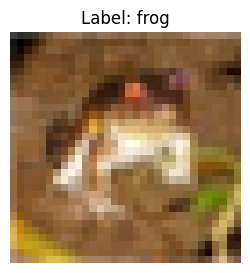

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

img, label = trainset[0]  # first sample
plt.figure(figsize=(3, 3))
plt.imshow(img.permute(1, 2, 0))
plt.axis('off')
plt.title(f'Label: {class_names[label]}')
plt.show()



Label occurrences in trainset:
Label 0: 5000
Label 1: 5000
Label 2: 5000
Label 3: 5000
Label 4: 5000
Label 5: 5000
Label 6: 5000
Label 7: 5000
Label 8: 5000
Label 9: 5000


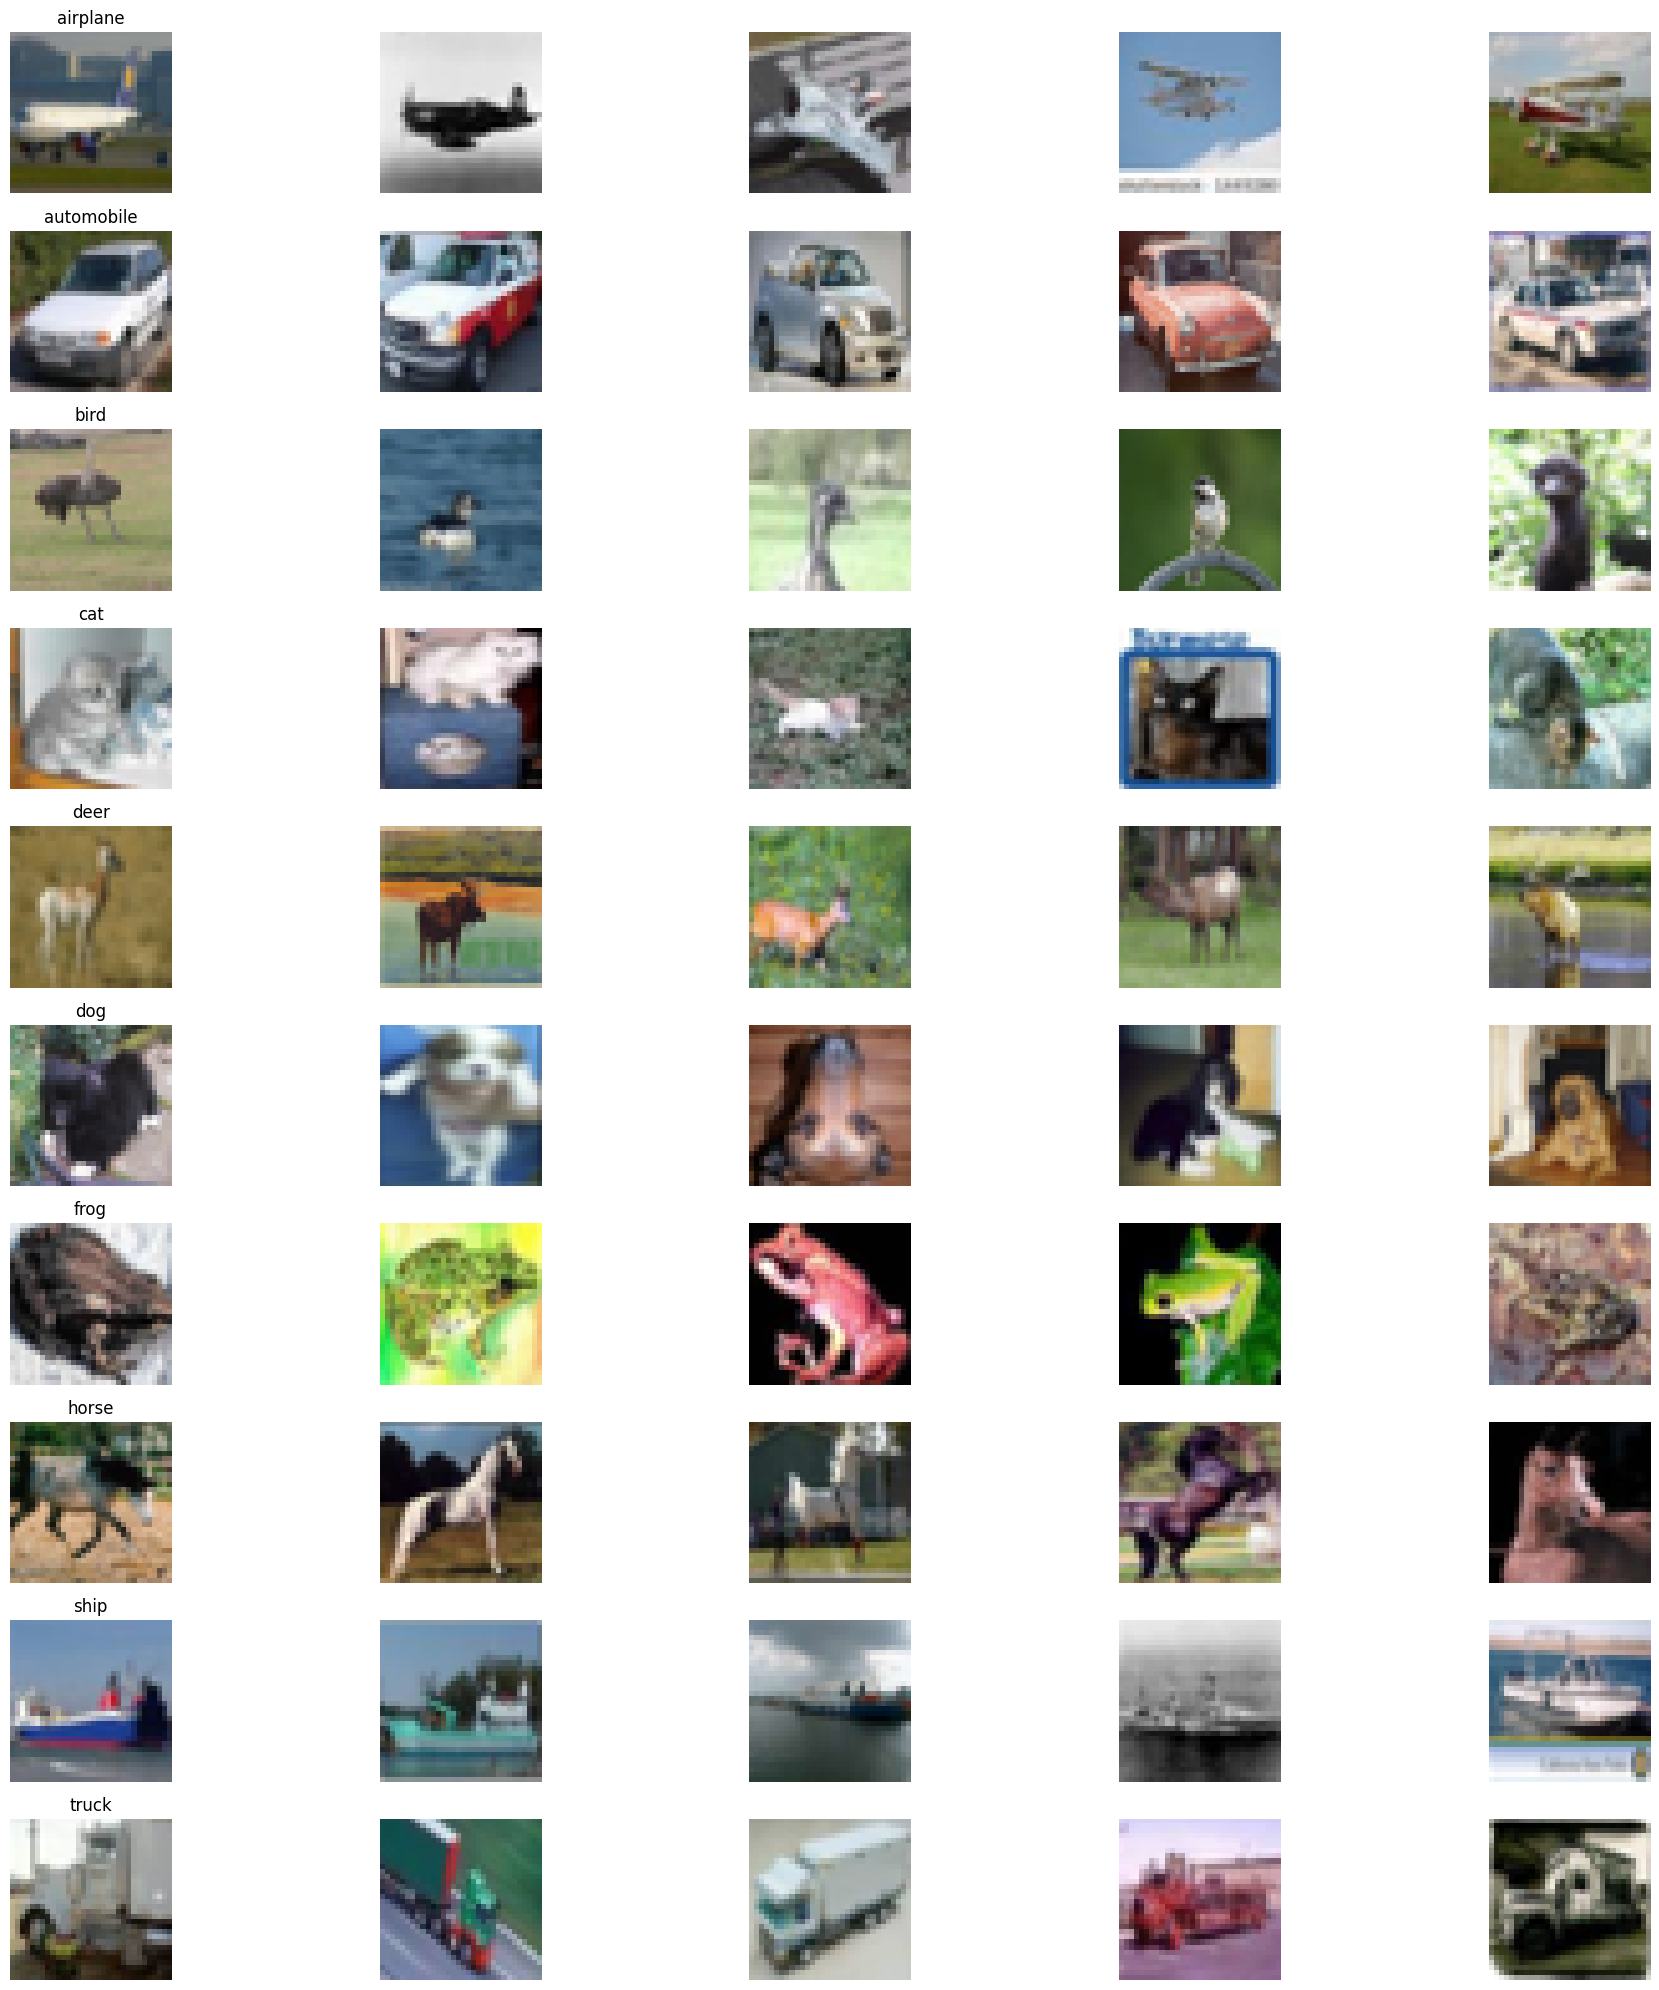

In [ ]:
from collections import Counter

import matplotlib.pyplot as plt

# Count occurrences of each label in trainset
labels = [trainset[i][1] for i in range(len(trainset))]
label_counts = Counter(labels)
print("Label occurrences in trainset:")
for label, count in sorted(label_counts.items()):
    print(f"Label {label}: {count}")


# Plot 5 images for each label
fig, axes = plt.subplots(10, 5, figsize=(20, 20))
for label in range(10):
    # Get indices of samples with this label
    indices = [i for i in range(len(trainset)) if trainset[i][1] == label][5:10]
    for j, idx in enumerate(indices):
        img, _ = trainset[idx]
        axes[label, j].imshow(img.permute(1, 2, 0))
        axes[label, j].axis('off')
        if j == 0:
            axes[label, j].set_title(f'{class_names[label]}', fontsize=12)
plt.tight_layout()
plt.show()

there is quite a lot of variance between the classes, but there are some classes which are more similar  to eachother, such as dog vs cat, and ship vs truck.

## Helper functions

In [4]:

if local_run:
    batch_size = 4
    num_workers = 0 #since we run on CPU locally
else:
    batch_size = 512
    num_workers = 6
    from google.colab import files


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

train_n = 50000
test_n = 10000

class CNNPreprocessor:
    def __init__(self):
        self.mean = None
        self.std = None
        self.fitted = False

    def __call__(self, img_tensor):
        return img_tensor

    def fit_and_normalize(self, features_list):
        stacked = torch.stack(features_list, dim=0) # concatenates to shape [len(features_list),3,64,64]
        self.mean = stacked.mean(dim=(0,2,3), keepdim=True)
        self.std = stacked.std(dim=(0,2,3), keepdim=True)
        self.std[self.std == 0] = 1.0
        self.fitted = True
        return (stacked - self.mean) / self.std

    def normalize(self, features):
        if not self.fitted:
            raise ValueError("Scaler not fitted yet")
        return (features - self.mean.squeeze(dim=0)) / self.std.squeeze(dim=0)

class CNNDataset(torch.utils.data.Dataset):
    def __init__(self, cnn_features, labels):
        self.features = cnn_features
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


def test_model(net, data_loader):
    net.eval()
    true_preds, count = 0., 0
    for imgs, labels in data_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            preds = net(imgs).argmax(dim=-1)
            true_preds += (preds == labels).sum().item()
            count += labels.shape[0]
    test_acc = true_preds / count
    return test_acc

def save_epoch_artifacts(model_name, epoch, all_outputs, grads):

    torch.save(all_outputs, f"models/{model_name}/{model_name}_outputs_epoch_{epoch}.pt")
    torch.save(grads, f"models/{model_name}/{model_name}_grads_epoch_{epoch}.pt")

def train_eval(model, model_name, local_run, criterion, optimizer, trainloader, testloader, valloader, device, skip_training, learning_rate=0.001, scheduler=None, num_epochs=10, patience=3, seed=42):
    global logging_active
    if skip_training:
        print("Pre-saved model exists, skipping training.")
        if local_run:
            map_location = torch.device('cpu')
        else:
            map_location = None
        state_dict = torch.load(f"models/{model_name}/{model_name}_prm.tar",map_location=map_location)
        model.load_state_dict(state_dict)
    else:
        print("No pre-saved model found, starting training...")
        set_seed(seed)
        optimizer = optimizer(model.parameters(), lr=learning_rate)
        best_val_epoch = -1
        val_scores = []
        train_accs = []
        val_accs = []
        logging_active = True
        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            samples = 0
            all_outputs = []
            batch = 0
            for inputs, labels in trainloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad() # clear grads
                outputs = model(inputs) # forward pass
                loss = criterion(outputs, labels) # compute loss
                loss.backward() # compute grads
                _, predicted = outputs.max(1)
                if batch == 0:
                    all_outputs.append(outputs.detach().cpu())
                    grads = {}
                    for name, param in model.named_parameters():
                        if param.grad is not None:
                            grads[name] = param.grad.detach().cpu().clone()
                optimizer.step() # update weights
                running_loss += loss.item() * inputs.size(0)
                samples += inputs.size(0)
                batch += 1
            model.eval()
            logging_active = False
            train_correct = 0
            train_total = 0

            with torch.no_grad():
                for inputs, labels in trainloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    _, predicted = outputs.max(1)
                    train_correct += (predicted == labels).sum().item()
                    train_total += labels.size(0)
            train_acc = train_correct / train_total

            train_accs.append(train_acc)
            val_acc = test_model(model, valloader)
            val_accs.append(val_acc)
            val_scores.append(val_acc)

            print(f"[Epoch {epoch+1:2d}] Training accuracy: {train_acc*100.0:05.2f}%, Validation accuracy: {val_acc*100.0:05.2f}%")
            save_epoch_artifacts(model_name, epoch, all_outputs, grads)

            if scheduler is not None:
                scheduler.step()

            if len(val_scores) == 1 or val_acc > val_scores[best_val_epoch]:
                print("\t   (New best performance, saving model parameters...)")
                state_dict = model.state_dict()
                torch.save(state_dict, f"{model_name}/{model_name}_prm.tar")
                best_val_epoch = epoch
            elif best_val_epoch <= epoch - patience:
                print(f"Early stopping due to no improvement over the last {patience} epochs")
                break

        # Save accuracies
        torch.save({'train_accs': train_accs, 'val_accs': val_accs}, f"{model_name}/{model_name}_accuracies.pt")

    test_acc = test_model(model, testloader)
    print(f"Final test accuracy: {test_acc*100:.2f}%")

    return test_acc


# Plotting functions
def plot_epoch_gradients(model_name, epoch=None):

    # Extract number of epochs from model name (last part after final underscore)
    if 'Two' in model_name or 'One' in model_name:
        num_epochs = int(model_name.split('_')[-1])
    else:
        num_epochs = int(model_name.split('_')[-2])

    # Use provided epoch or default to final epoch
    if epoch is None:
        epoch = num_epochs - 1
    elif epoch < 0 or epoch >= num_epochs:
        raise ValueError(f"Epoch {epoch} is out of range. Model has {num_epochs} epochs (0-{num_epochs-1}).")

    # Load gradients for specified epoch
    grads_path = f"models/{model_name}/{model_name}_grads_epoch_{epoch}.pt"
    grads = torch.load(grads_path)

    # Extract weight layer names (exclude bias)
    weight_layers = [name for name in grads.keys() if 'bias' not in name]

    # Plot histogram of gradients for each weight layer
    fig, axes = plt.subplots(1, len(weight_layers), figsize=(4*len(weight_layers), 4))
    if len(weight_layers) == 1:
        axes = [axes]

    for layer_idx, layer_name in enumerate(weight_layers):
        grad_tensor = grads[layer_name].flatten()
        mean_grad = grad_tensor.mean().item()
        std_grad = grad_tensor.std().item()

        axes[layer_idx].hist(grad_tensor.numpy(), bins=30, edgecolor='black', alpha=0.7)
        axes[layer_idx].set_title(f'{layer_name}\nEpoch {epoch}\nMean: {mean_grad:.4f}, Std: {std_grad:.4f}')
        axes[layer_idx].set_xlabel('Gradient Value')
        axes[layer_idx].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

def plot_epoch_accuracies(model_name):

    # Load accuracies
    acc_path = f"models/{model_name}/{model_name}_accuracies.pt"
    accuracies = torch.load(acc_path)

    train_accs = accuracies['train_accs']
    val_accs = accuracies['val_accs']

    epochs = range(len(train_accs))

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train_accs, label='Train Accuracy', marker='o')
    plt.plot(epochs, val_accs, label='Validation Accuracy', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Train and Validation Accuracy for {model_name}')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_epoch_outputs(model_name, epoch=None):

    # Extract number of epochs from model name (last part after final underscore)
    if 'Two' in model_name or 'One' in model_name:
        num_epochs = int(model_name.split('_')[-1])
    else:
        num_epochs = int(model_name.split('_')[-2])

    # Use provided epoch or default to final epoch
    if epoch is None:
        epoch = num_epochs - 1
    elif epoch < 0 or epoch >= num_epochs:
        raise ValueError(f"Epoch {epoch} is out of range. Model has {num_epochs} epochs (0-{num_epochs-1}).")

    # Load outputs for specified epoch
    outputs_path = f"models/{model_name}/{model_name}_outputs_epoch_{epoch}.pt"
    outputs = torch.load(outputs_path)


    output_tensor = outputs[0].flatten()

    # Plot histogram of outputs
    plt.figure(figsize=(8, 3))
    plt.hist(output_tensor.numpy(), bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Output Value (Logit)')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Model Outputs for {model_name} at Epoch {epoch}')
    plt.grid(True)
    plt.show()




Using device: cpu


## defining datasets

In [5]:
from torch.utils.data import Subset

# Non augumented

mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.5, 0.5, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_full_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)

train_full_nonaug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=test_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

indices = list(range(len(train_full_aug)))
train_size = int(0.8 * len(indices))

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full_nonaug, train_indices)
val_dataset   = Subset(train_full_nonaug, val_indices)

cnn_trainloader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=num_workers)
cnn_valloader = torch.utils.data.DataLoader(val_dataset, batch_size, shuffle=False, num_workers=num_workers)
cnn_testloader = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False, num_workers=num_workers)

c:\Users\barba\Documents\ProfessionalBetterment\CIFAR10_classification\CIFAR10_classification\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
from torch.utils.data import Subset

# augumented

mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]

train_dataset_aug = Subset(train_full_aug, train_indices)

cnn_trainloader_da = torch.utils.data.DataLoader(train_dataset_aug, batch_size, shuffle=True, num_workers=num_workers)
cnn_valloader_da = torch.utils.data.DataLoader(val_dataset, batch_size, shuffle=False, num_workers=num_workers)
cnn_testloader_da = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False, num_workers=num_workers)


Below we show a few augumented images, alongside their original, non-augumented versions. We keep the transformations quite modest, so that the augmented versions still look like realistic representatives of a class.

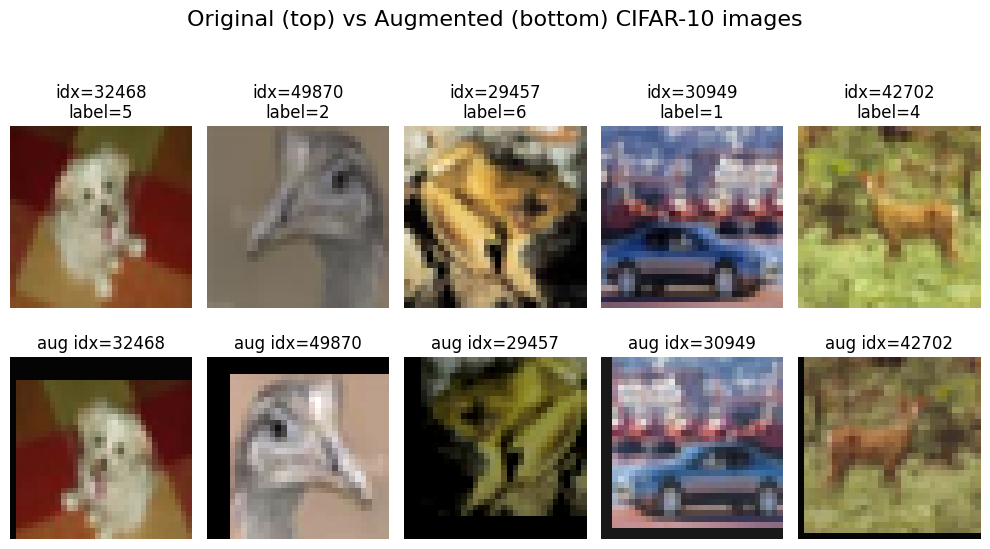

In [ ]:
indices = random.sample(range(len(train_dataset)), 5)

fig, axes = plt.subplots(2, 5, figsize=(10, 6))
fig.suptitle("Original (top) vs Augmented (bottom) CIFAR-10 images", fontsize=16)

for col, idx in enumerate(indices):
    idx = random.randint(0, len(train_dataset)-1)  # ensure idx is valid
    img_orig, label = train_dataset[idx]
    img_aug, _ = train_dataset_aug[idx]  # trainset has augmentation transform

    axes[0, col].imshow(img_orig.permute(1, 2, 0))
    axes[0, col].set_title(f"idx={idx}\nlabel={label}")
    axes[0, col].axis("off")

    axes[1, col].imshow(img_aug.permute(1, 2, 0))
    axes[1, col].set_title(f"aug idx={idx}")
    axes[1, col].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Different architectures

### One and two layers

Pre-saved model exists, skipping training.
Final test accuracy: 59.84%


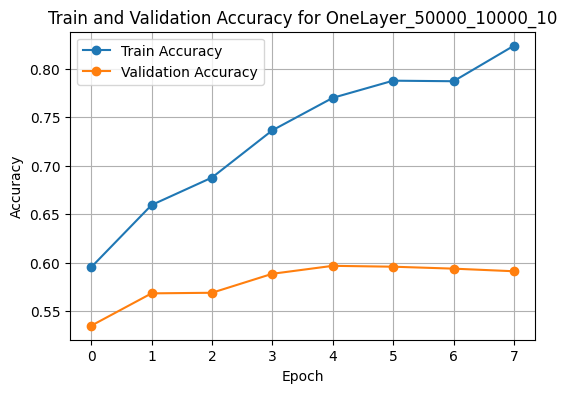

In [214]:
test_acc_dict = {}

# one layer, no pooling
num_epochs = 10
model_name = f"OneLayer_{train_n}_{test_n}_{num_epochs}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.fc = nn.Linear(16 * 32 * 32, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SimpleCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))
skip_training = params_saved and outputs_saved and grads_saved

test_acc = train_eval(model, model_name,local_run,nn.CrossEntropyLoss(),torch.optim.Adam,cnn_trainloader, cnn_testloader, cnn_valloader,device,skip_training,num_epochs = num_epochs)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]


if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)




The difference between the train and validation accuracy is over 15% in the best performing model, and around 23% in the final epoch. This indicated severe overfitting. However, we see that the test accuracy is around 60%, which matches the accuracy of the SVM model, as we expected.
We increase the number of layers to two.

Pre-saved model exists, skipping training.
Final test accuracy: 63.81%


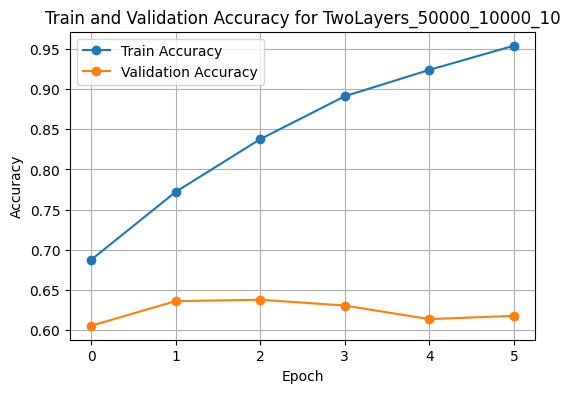

In [207]:
# two layers, no pooling
num_epochs = 10
model_name = f"TwoLayers_{train_n}_{test_n}_{num_epochs}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class TwoLayerCNN(nn.Module):
    def __init__(self):
        super(TwoLayerCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc = nn.Linear(32 * 32 * 32, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = TwoLayerCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

test_acc = train_eval(model, model_name,local_run,nn.CrossEntropyLoss(),torch.optim.Adam,cnn_trainloader, cnn_testloader, cnn_valloader, device,skip_training,num_epochs=num_epochs,patience=3, learning_rate=0.001)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")


plot_epoch_accuracies(model_name)

plot_epoch_outputs(model_name, epoch=5)
epoch_outputs = torch.load(f"{model_name}/{model_name}_outputs_epoch_5.pt")
print(f"Epoch 5 outputs mean: {epoch_outputs[0].mean()}")

The mean of the logits is extreme, around -5.5. Saturation of the outputs can indicate that the model is producing very confident predictions, which can lead to vanishing gradients and stop the learning process. If the outputs are mostly clustered around extreme values (e.g., very high or very low logits), it may suggest that the model is overfitting or that the learning rate is too high, causing it to converge to a suboptimal solution. In these cases, it might be beneficial to adjust the learning rate, add regularization or early stopping to prevent overfitting.

Since the FC layer is so large, the model is likely relying on it to memorize specific patterns in the data. Therefore, to combat overfitting, we introduce pooling.


Pre-saved model exists, skipping training.
Final test accuracy: 68.41%


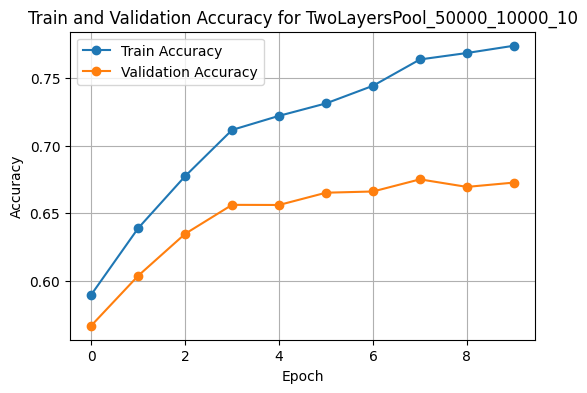

In [211]:
# two layers, pooling
num_epochs = 10

model_name = f"TwoLayersPool_{train_n}_{test_n}_{num_epochs}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class TwoLayerCNN(nn.Module):
    def __init__(self):
        super(TwoLayerCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = TwoLayerCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

test_acc = train_eval(model, model_name,local_run,nn.CrossEntropyLoss(),torch.optim.Adam,cnn_trainloader, cnn_testloader, cnn_valloader, device,skip_training,num_epochs=num_epochs,patience=3, learning_rate=0.001)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")


plot_epoch_accuracies(model_name)

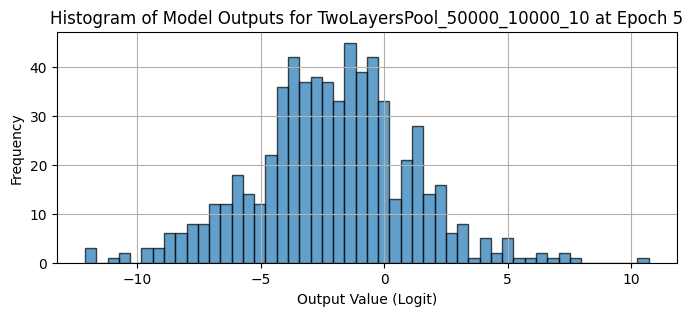

Epoch 5 outputs mean: -2.1253349781036377


In [212]:
plot_epoch_outputs(model_name, epoch=5)
epoch_outputs = torch.load(f"models/{model_name}/{model_name}_outputs_epoch_5.pt")
print(f"Epoch 5 outputs mean: {epoch_outputs[0].mean()}")


Here we see that overfitting is greately reduced, as the gap between train and val accuracy in the best performing model drops from 20% to 9%. The mean logit is now -2.12, a much more moderate value. The next technique we use to combat overfitting is dropout.
Dropout randomly sets a fraction of the input units to 0 at each update during training time, which helps prevent overfitting by introducing noise and forcing the network to learn more robust features.

Pre-saved model exists, skipping training.
Final test accuracy: 67.45%


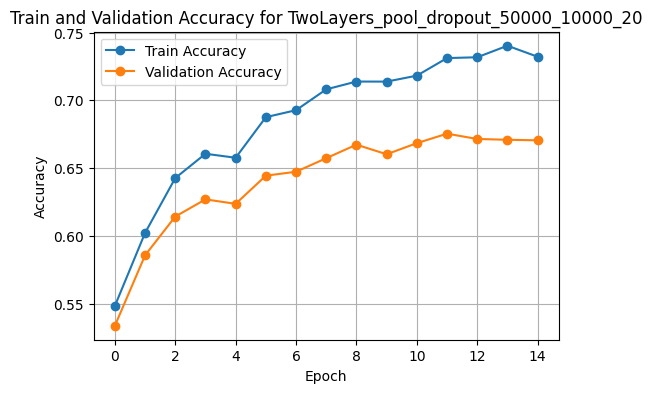

In [34]:
# two layers, pooling and dropout
num_epochs = 20
model_name = f"TwoLayers_pool_dropout_{train_n}_{test_n}_{num_epochs}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class TwoLayerCNN(nn.Module):
    def __init__(self):
        super(TwoLayerCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout2d(p=0.5)
        self.fc = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = TwoLayerCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), torch.optim.Adam, cnn_trainloader, cnn_testloader, cnn_valloader, device, skip_training, num_epochs=num_epochs)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)


Pre-saved model exists, skipping training.
Final test accuracy: 61.26%


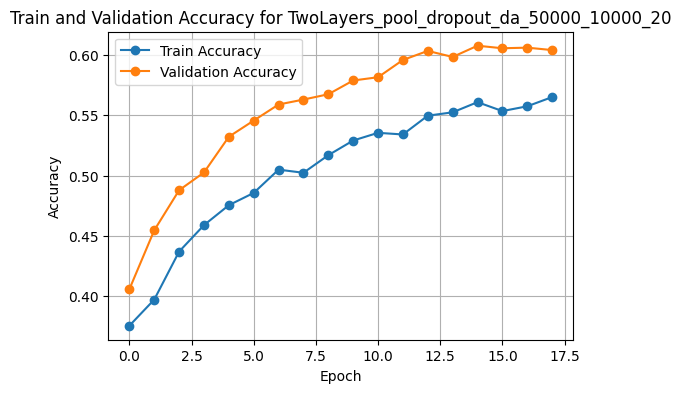

In [255]:
# two layers, pooling, dropout and data augumentation
num_epochs = 20
model_name = f"TwoLayers_pool_dropout_da_{train_n}_{test_n}_{num_epochs}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class TwoLayerCNN(nn.Module):
    def __init__(self):
        super(TwoLayerCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout2d(p=0.5)
        self.fc = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = TwoLayerCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), torch.optim.Adam, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs=num_epochs)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)


Note that validation accuracy is now higher than training accuracy. This is because both dropout and data augumentation introduce stochasticity into training, whereas they are not performed on validation.
Since the model with data augumentaiton is shown a greater variety of data, and the training images are not repeated on each epoch, the model's ability to overfit decreases. Indeed, the gap between val and train accuracy is now only 5%.
We would expect the model with data augumentation to perform better than the model without it. This is not the case, likely because the models haven't been trained for long enough. Patience is set to 3, which is quite small.

However, let's move on to a larger network. The following network contains four layers, data augumentaiton and pooling. It is trianed on 60 epochs with patience equal to 7.

### Four layers

Pre-saved model exists, skipping training.
Final test accuracy: 74.09%


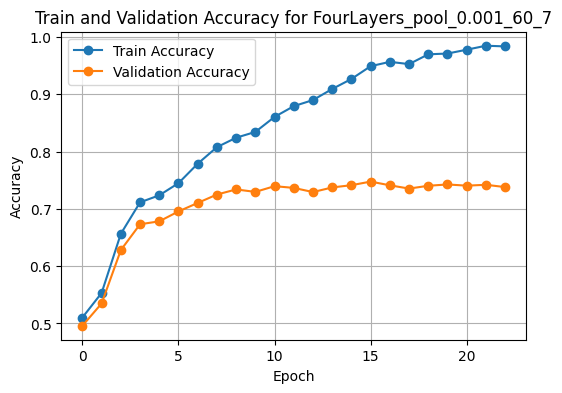

In [222]:
# four layers, pooling, lc
learning_rate = 0.001
num_epochs = 60
patience = 7
model_name = f"FourLayers_pool_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)
class FourLayerPoolCNN(nn.Module):
    def __init__(self):
        super(FourLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 96, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(96, 128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128*8*8, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = FourLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

test_acc = train_eval(model, model_name,local_run,nn.CrossEntropyLoss(),torch.optim.Adam,cnn_trainloader, cnn_testloader, cnn_valloader, device,skip_training,num_epochs = num_epochs,patience = patience, learning_rate = learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

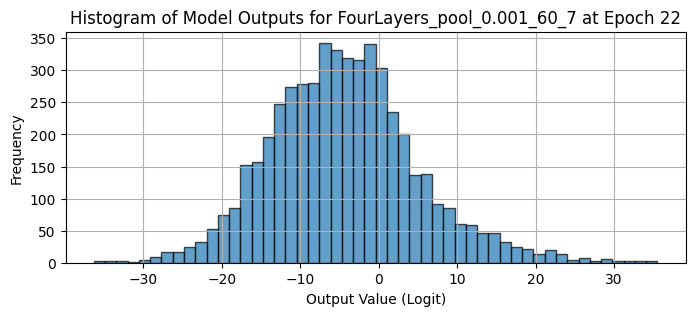

Epoch 22 outputs mean: -4.40995979309082


In [223]:
plot_epoch_outputs(model_name, epoch=22)
epoch_outputs = torch.load(f"models/{model_name}/{model_name}_outputs_epoch_22.pt")
print(f"Epoch 22 outputs mean: {epoch_outputs[0].mean()}")


Pre-saved model exists, skipping training.
Final test accuracy: 81.73%


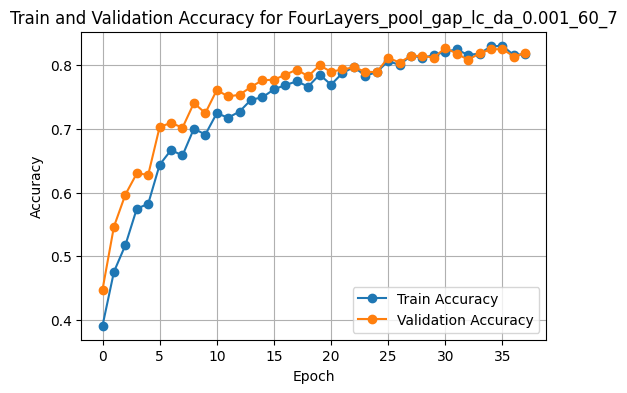

In [224]:
# four layers, pooling, lc, da
learning_rate = 0.001
num_epochs = 60
patience = 7
model_name = f"FourLayers_pool_gap_lc_da_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)
class FourLayerPoolCNN(nn.Module):
    def __init__(self):
        super(FourLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 96, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(96, 128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128*8*8, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = FourLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

test_acc = train_eval(model, model_name,local_run,nn.CrossEntropyLoss(),torch.optim.Adam,cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device,skip_training,num_epochs = num_epochs,patience = patience, learning_rate = learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

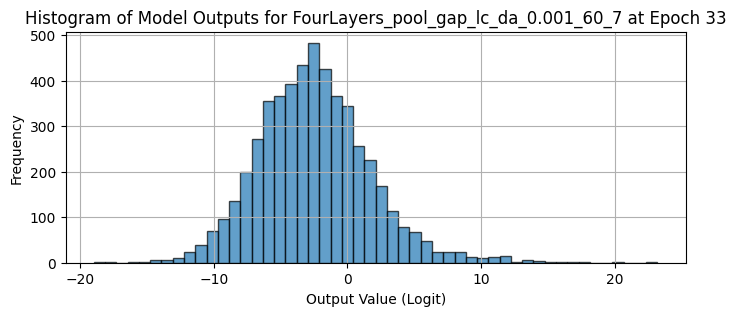

Epoch 33 outputs mean: -2.4978315830230713


In [225]:
plot_epoch_outputs(model_name, epoch=33)
epoch_outputs = torch.load(f"models/{model_name}/{model_name}_outputs_epoch_33.pt")
print(f"Epoch 33 outputs mean: {epoch_outputs[0].mean()}")

Compared to the best performing two layer network, the accuracy increased by about 14% to 81.8%. (Note that the comparison is not exactly fair as the two layer network was trained on less epochs). The graph shows convergence as the validation accuracy settles at just over 80%, and there is no sign of overfitting.

Let's naively increase the depth and see what happens. For now, we remove data augumentation.

### 6 layers

Pre-saved model exists, skipping training.
Final test accuracy: 76.20%


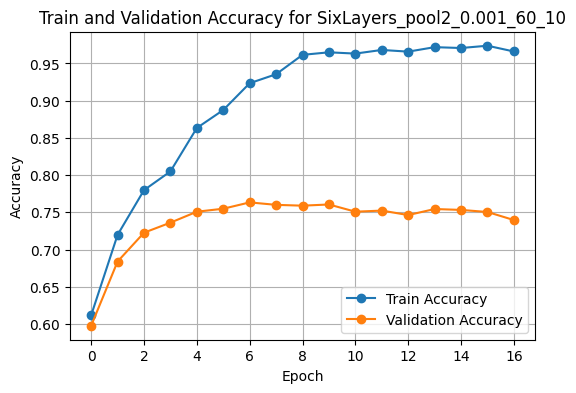

In [226]:
# 6 layers, pooling
learning_rate = 0.001
num_epochs = 60
patience = 10

model_name = f"SixLayers_pool2_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)
class FourLayerPoolCNN(nn.Module):
    def __init__(self):
        super(FourLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128*8*8, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = FourLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name,local_run,nn.CrossEntropyLoss(),optimizer_callable,cnn_trainloader, cnn_testloader, cnn_valloader, device,skip_training,num_epochs = num_epochs,patience = patience, learning_rate = learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

We again see signs of severe overfitting, as model capacity increases.

Note also that when going from a four layer network with data augumentation to a 6 layer network without data augumentation, the test set accuracy drops by 6%. More layers is not necessarily the best improvement we can make to an architecture. Let's check how the performance changes when we add data augumentation.

Pre-saved model exists, skipping training.
Final test accuracy: 84.81%


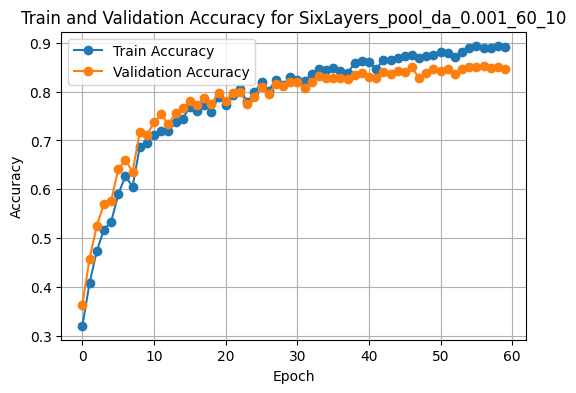

In [227]:
# 6 layers, pooling, da
learning_rate = 0.001
num_epochs = 60
patience = 10

model_name = f"SixLayers_pool_da_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)
class FourLayerPoolCNN(nn.Module):
    def __init__(self):
        super(FourLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128*8*8, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = FourLayerPoolCNN().to(device)
logging_active = False
activation_outputs1 = {}
def make_hook(name):
    def hook(module, input, output):
        if logging_active:
            x = output
            norm = x.pow(2).mean().sqrt().item()
            activation_outputs1.setdefault(name, []).append(norm)
    return hook

for name, layer in model.named_modules():
    if isinstance(layer, nn.Conv2d):
        layer.register_forward_hook(make_hook(name))

params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))
skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)

optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name,local_run,nn.CrossEntropyLoss(),optimizer_callable,cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device,skip_training,num_epochs = num_epochs,patience = patience, learning_rate = learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  activation_outputs_dict = {k:v for k, v in activation_outputs1.items()}
  torch.save(activation_outputs_dict, f"{model_name}/{model_name}_activation_outputs.pt")
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

Overfitting is greately reduced as generalization improves: the model isn't shown the same images on each epoch, meaning that it cannot memorise. It is also exposed to a greater variation in data. As the model is no longer simply memorizing the pattern of the train dataset, and is actually learning now, its validation score increases.

The following plots show the root mean square (RMS) of the outputs of each of the convolutional layers retrieved during training, plotted against the training batch. As we have 0.8 * 50000 = 40000 training points, split into batches of size 512, we have 79 training batches in each epoch. For 60 epochs, that gives 4740 batches. We make these plots to study the size of the outputs of each layer, which are then fed into the subsequent layer. We take the RMS as a measure of size, since it accounts for the number of features in each layer and the size of the input to each layer.

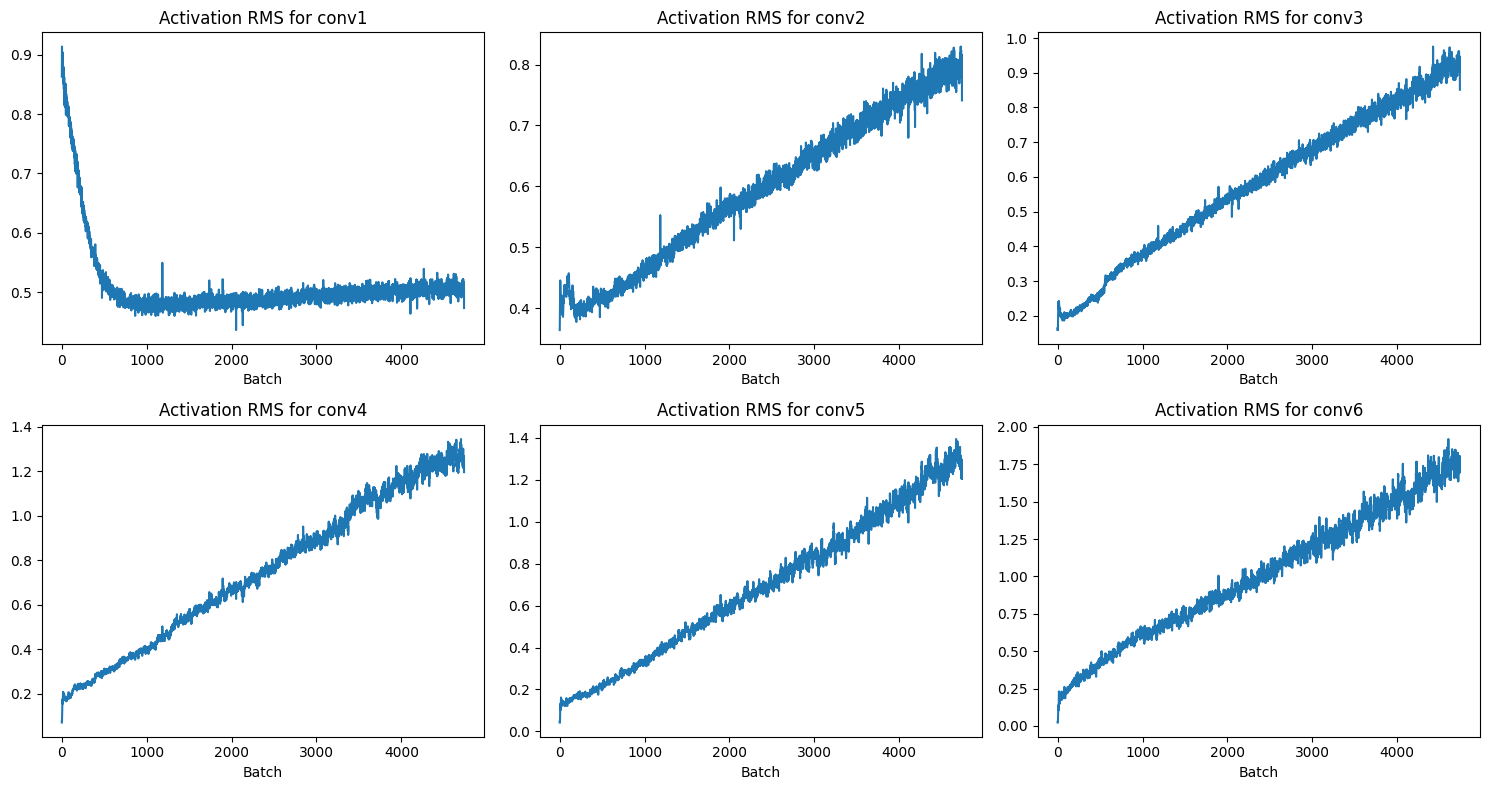

In [228]:
model_name = f"SixLayers_pool_da_{learning_rate}_{num_epochs}_{patience}"
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
i,j = 0,0
for layer in model.named_modules():
     if isinstance(layer[1], nn.Conv2d):
        layer = layer[0]
        activation_rms = torch.load(f"models/{model_name}/{model_name}_activation_outputs.pt")[layer]
        axes[i, j].plot(activation_rms)
        axes[i, j].set_title(f"Activation RMS for {layer}")
        axes[i, j].set_xlabel("Batch")
        j += 1
        if j == 3:
            j = 0
            i += 1
plt.tight_layout()

<!-- Note that for layers 2-6, the RMS of the activation functions incrase as training progresses. The model seems to learn parameters which give outputs which are larger in the RMS sense. This is in line with intuition: larger outputs give more confident predictions when fed through a ReLu function followed by a softmax function. (but this is not true, the model still applies the fc function. and besides softmax is applied only in last layer) -->

<!-- The plot for conv 1 does actually show the same behaviour (it is an increasing function of the batch) after the initial phase.  -->

We see that the output size seems to increase within the layers. Each subsequent layer is receiving inputs which are larger in the RMS sense. This is known as internal covariate shift: the input to each module has a different distribution. This leads to sub-optimal training. One way to ammend this is through batch normalization.

Pre-saved model exists, skipping training.
Final test accuracy: 86.30%


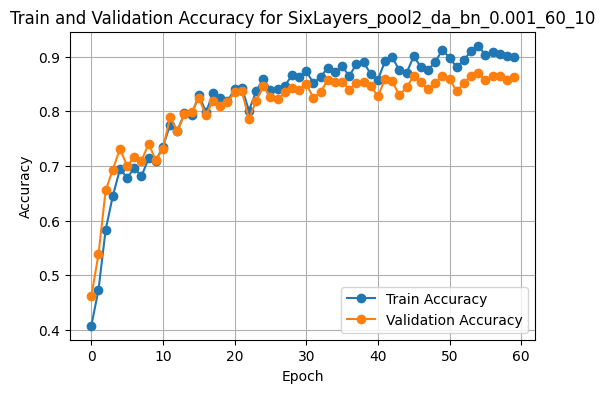

In [229]:

# 6 layers, pooling, da, batchnorm
learning_rate = 0.001
num_epochs = 60
patience = 10

model_name = f"SixLayers_pool2_da_bn_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SixLayerPoolCNN().to(device)

logging_active = False
activation_outputs1 = {}
def make_hook(name):
    def hook(module, input, output):
        if logging_active:
            x = output
            norm = x.pow(2).mean().sqrt().item()
            activation_outputs1.setdefault(name, []).append(norm)
    return hook

for name, layer in model.named_modules():
    if isinstance(layer, nn.BatchNorm2d) or isinstance(layer, nn.Linear):
        layer.register_forward_hook(make_hook(name))

params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate =learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  activation_outputs_dict = {k:v for k, v in activation_outputs1.items()}
  torch.save(activation_outputs_dict, f"{model_name}/{model_name}_activation_outputs.pt")
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

Note that we reach 80% accuracy in about half the time as without batch norm. Next, we plot the RMS of the outputs of each batchnorm layer.

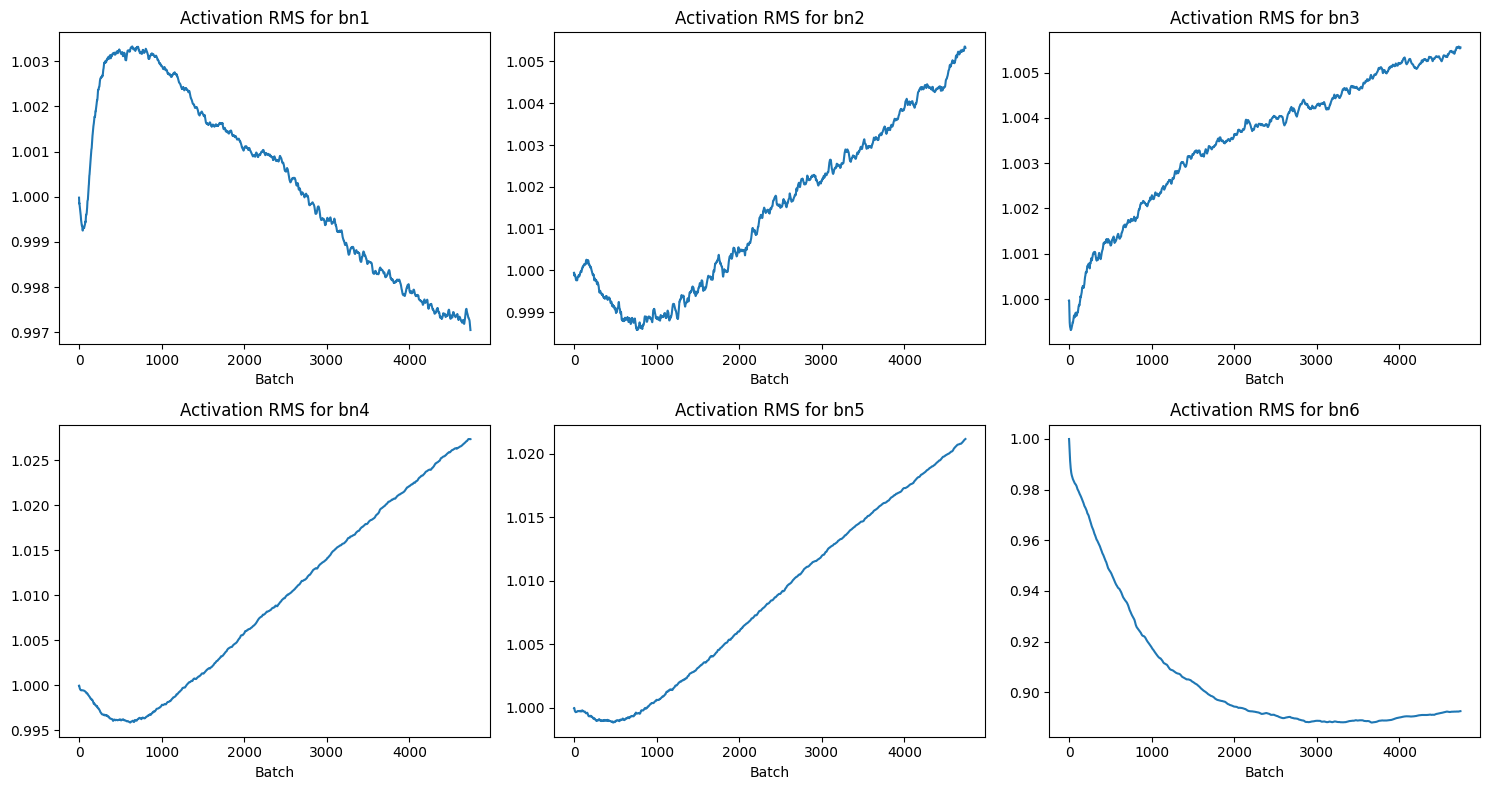

In [230]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
i,j = 0,0
for layer in model.named_modules():
     if isinstance(layer[1], nn.BatchNorm2d):
        layer = layer[0]
        activation_rms_bn = torch.load(f"models/{model_name}/{model_name}_activation_outputs.pt")[layer]
        axes[i, j].plot(activation_rms_bn)
        axes[i, j].set_title(f"Activation RMS for {layer}")
        axes[i, j].set_xlabel("Batch")
        j += 1
        if j == 3:
            j = 0
            i += 1
plt.tight_layout()

The outputs are now on an equal scale throughout the layers. Note also that the output rms varies less from one batch to another, when compared to the model without batchnorm. This makes sense, since the data is normalized first to 0 mean and unit variance, and then a scale and shift parameters are applied. For each layer, these parameters are fairly constant accross the batches, as evidenced by the following printout. For each batch norm layer, we retrieve the beta and gamma parameters for each batch, and we display the standard deviation across the batches. The standard deviations are small, and smaller for the deeper layers. This can also be observed from the plots, with the deeper layers showing smoother plots.

In [231]:
for name, layer in model.named_modules():
    if isinstance(layer, nn.BatchNorm2d):
        g_std = layer.weight.data.std()
        g_mean = layer.weight.data.mean()
        b_mean = layer.bias.data.mean()
        b_std = layer.bias.data.std()
        print(f"{name}: beta mean={b_mean:.4f}, beta std={b_std:.4f}, gamma mean={g_mean:.4f}, gamma std={g_std:.4f}")

bn1: beta mean=0.1928, beta std=0.2438, gamma mean=0.9403, gamma std=0.1296
bn2: beta mean=-0.1693, beta std=0.0688, gamma mean=0.9850, gamma std=0.0742
bn3: beta mean=-0.1704, beta std=0.0577, gamma mean=0.9864, gamma std=0.0737
bn4: beta mean=-0.3455, beta std=0.0857, gamma mean=0.9595, gamma std=0.0541
bn5: beta mean=-0.3524, beta std=0.0624, gamma mean=0.9528, gamma std=0.0499
bn6: beta mean=-0.3305, beta std=0.0380, gamma mean=0.8253, gamma std=0.0470


Finally, we plot the RMS of the fully connected layer outputs.

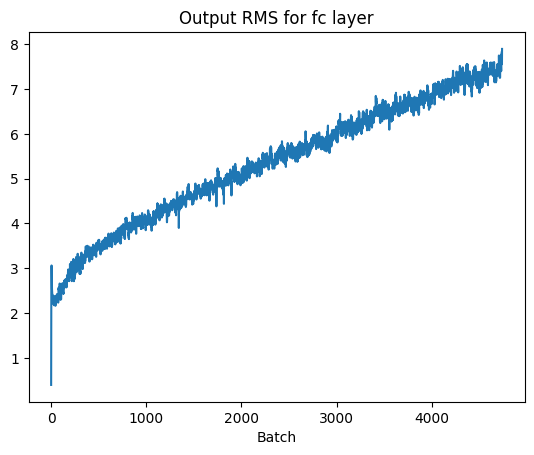

In [233]:
activation_rms_bn = torch.load(f"models/{model_name}/{model_name}_activation_outputs.pt")["fc"]
plt.plot(activation_rms_bn)
plt.title("Output RMS for fc layer")
plt.xlabel("Batch")
plt.show()

As an aside, note that the RMS of the outputs of the fully connected layer incrases as training progresses. The model seems to learn parameters which give outputs which are larger in the RMS sense. This is in line with intuition: larger outputs give more confident predictions when fed through a softmax function.

Pre-saved model exists, skipping training.
Final test accuracy: 86.96%


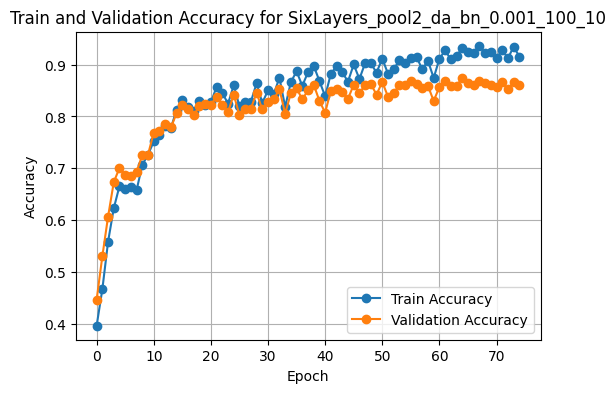

In [234]:
# 6 layers, pooling, da, batchnorm, 100 epochs
learning_rate = 0.001
num_epochs = 100
patience = 10

model_name = f"SixLayers_pool2_da_bn_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)



    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


model = SixLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate =learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

Another option is to reduce the number of times we perform pooling. Each time we perform pooling, we reduce the image size by a half, so reducing the pooling layers will leave the images at a higher resolution, which can be benefitial. On the other hand, the number of parameters is quite large, compared to the network with more aggressive pooling. 

Pre-saved model exists, skipping training.
Final test accuracy: 86.42%


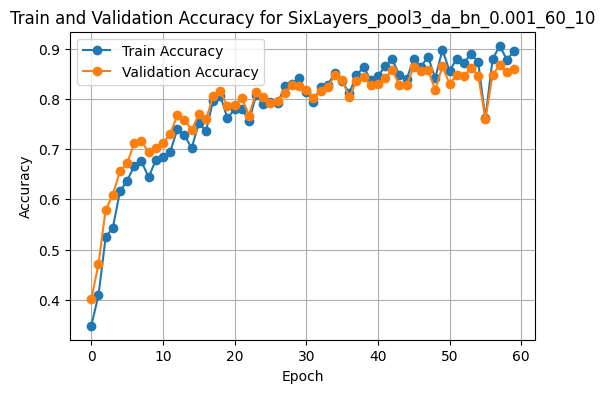

In [235]:
# 6 layers, less pooling, da, batchnorm
learning_rate = 0.001
num_epochs = 60
patience = 10

model_name = f"SixLayers_pool3_da_bn_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 16 * 16, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SixLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate =learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

In the following cell, we return to the original pooling strategy and add skip connections to the network. In deep networks, gradients can become very small as they are backpropagated through many layers, making it difficult for the network to learn. Skip connections allow gradients to bypass certain layers, which helps maintain stronger gradient signals and facilitates learning in deeper networks. 
They also improve information flow: skip connections provide an alternative path for information to travel through the network, which can help in preserving important features and reducing information loss during the forward pass.

Pre-saved model exists, skipping training.
Final test accuracy: 85.72%


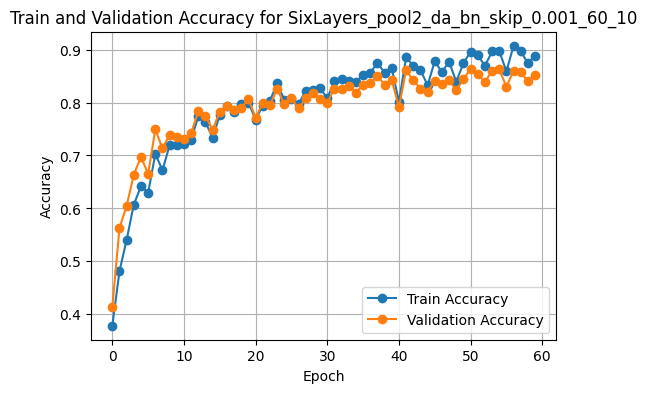

In [236]:
# 6 layers, pooling, da, batchnorm, skip connections
learning_rate = 0.001
num_epochs = 60
patience = 10

model_name = f"SixLayers_pool2_da_bn_skip_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)

    def forward(self, x):
        # Block 1: conv1 + conv2 with skip
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  # skip connection
        x = self.pool(x)

        # Block 2: conv3 + conv4 with skip
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  # skip connection
        x = self.pool(x)

        # Block 3: conv5 + conv6 with skip
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  # skip connection

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SixLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)

optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate = learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

Pre-saved model exists, skipping training.
Final test accuracy: 86.60%


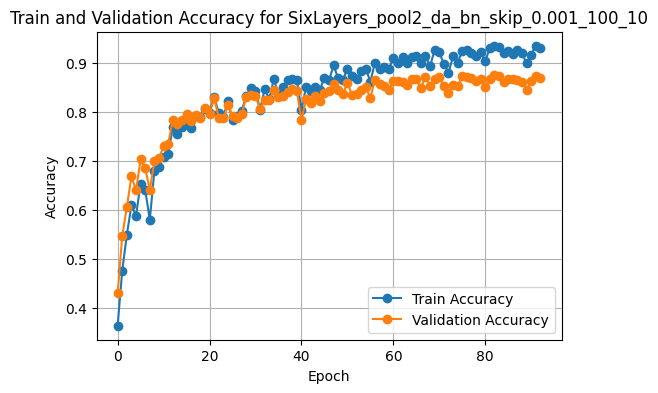

In [237]:
# 6 layers, pooling, da, batchnorm, skip connections, 100 epochs
learning_rate = 0.001
num_epochs = 100
patience = 10

model_name = f"SixLayers_pool2_da_bn_skip_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)

    def forward(self, x):
        # Block 1: conv1 + conv2 with skip
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  # skip connection
        x = self.pool(x)

        # Block 2: conv3 + conv4 with skip
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  # skip connection
        x = self.pool(x)

        # Block 3: conv5 + conv6 with skip
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  # skip connection

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SixLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)

optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate = learning_rate)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

The next addition we explore is learning rate schedulers. We will implement a simple step decay scheduler that reduces the learning rate by a factor of 0.5 every 10 epochs. 
This can help the model converge better by allowing it to take larger steps in the beginning and smaller steps as it gets closer to a minimum.

Pre-saved model exists, skipping training.
Final test accuracy: 85.96%


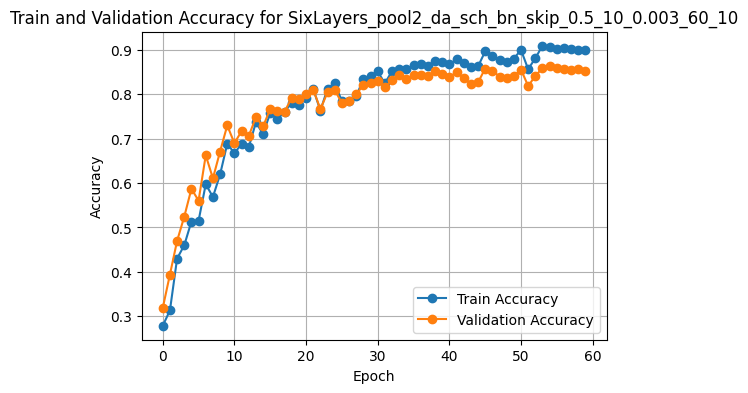

In [238]:
# 6 layers, pooling, da, sch, batchnorm, skip connections
learning_rate = 0.003
num_epochs = 60
patience = 10

gamma = 0.5
step_size = 10

model_name = f"SixLayers_pool2_da_sch_bn_skip_{gamma}_{step_size}_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)

    def forward(self, x):
        # Block 1: conv1 + conv2 with skip
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  # skip connection
        x = self.pool(x)

        # Block 2: conv3 + conv4 with skip
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  # skip connection
        x = self.pool(x)

        # Block 3: conv5 + conv6 with skip
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  # skip connection

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SixLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_instance, step_size=step_size, gamma=gamma)
optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate = scheduler)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

In the following cell we use a cosine learning rate scheduler instead of a step scheduler. Compared to the step scheduler, the cosine scheduler starts at a certain learning rate and gradually decreases it following a cosine curve, which can help the model converge more smoothly and potentially achieve better performance. 
The step scheduler, on the other hand, reduces the learning rate abruptly at specified intervals. By using a cosine scheduler, we aim to improve the model's ability to find a better local minimum in the loss landscape, ultimately enhancing its generalization performance on the test set. However, as we will see, performance does not match that of a step scheduler. 

Pre-saved model exists, skipping training.
Final test accuracy: 82.71%


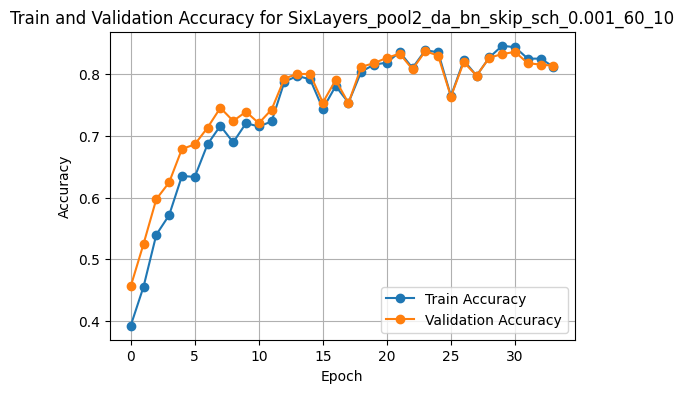

In [239]:
# 6 layers, pooling, da, sch, batchnorm, skip connections
learning_rate = 0.001
num_epochs = 60
patience = 10

model_name = f"SixLayers_pool2_da_bn_skip_sch_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)

    def forward(self, x):
        # Block 1: conv1 + conv2 with skip
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  # skip connection
        x = self.pool(x)

        # Block 2: conv3 + conv4 with skip
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  # skip connection
        x = self.pool(x)

        # Block 3: conv5 + conv6 with skip
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  # skip connection

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SixLayerPoolCNN().to(device)
params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))

skip_training = params_saved and outputs_saved and grads_saved

optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_instance, T_max=num_epochs)
optimizer_callable = lambda params, lr: optimizer_instance

test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate = scheduler)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
test_acc_dict[model_name] = [test_acc,num_params]

if not local_run and not skip_training:
  !zip -r {model_name}.zip {model_name}
  files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

## Determining the best model

In [7]:
# Model 1: 6 layers, pooling, da, batchnorm
learning_rate = 0.001
num_epochs = 100
patience = 20

model_name = f"SixLayers_pool2_da_bn_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)


    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
    

test_acc_model1 = []
if not local_run:
    for i in range(2):
        model = SixLayerPoolCNN().to(device)
        skip_training = False
        optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
        optimizer_callable = lambda params, lr: optimizer_instance
        test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate =learning_rate, seed = i)
        test_acc_model1.append(test_acc)
        torch.save(test_acc_model1, f"{model_name}/{model_name}_test_acc_bm.pt")
        !zip -r {model_name}.zip {model_name}
        files.download(f"{model_name}.zip")

In [8]:
test_acc_model1 =torch.load(f"models/{model_name}_test_acc_bm.pt")
print(f"Test accuracies across 3 runs: {test_acc_model1}")
print(f"Mean test accuracy: {np.mean(test_acc_model1):.4f}, Std: {np.std(test_acc_model1):.4f}")

Test accuracies across 3 runs: [0.855, 0.8612, 0.871]
Mean test accuracy: 0.8624, Std: 0.0066


In [241]:
# Model2 : 6 layers, less pooling, da, batchnorm
learning_rate = 0.001
num_epochs = 100
patience = 20

model_name = f"SixLayers_pool3_da_bn_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 16 * 16, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
    
test_acc_model2 = []
if not local_run:
    for i in range(2):
        model = SixLayerPoolCNN().to(device)
        skip_training = False
        optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
        optimizer_callable = lambda params, lr: optimizer_instance
        test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate =learning_rate, seed = i)
        test_acc_model2.append(test_acc)
        torch.save(test_acc_model2, f"{model_name}/{model_name}_test_acc_model2.pt")
        !zip -r {model_name}.zip {model_name}
        files.download(f"{model_name}.zip")


In [242]:
test_acc_model2 =torch.load(f"models/{model_name}_test_acc_model2.pt")
print(f"Test accuracies across 3 runs: {test_acc_model2}")
print(f"Mean test accuracy: {np.mean(test_acc_model2):.4f}, Std: {np.std(test_acc_model2):.4f}")

Test accuracies across 3 runs: [0.866, 0.8656, 0.855]
Mean test accuracy: 0.8622, Std: 0.0051


In [243]:
# Model3: 6 layers, pooling, da, batchnorm, skip connections
learning_rate = 0.001
num_epochs = 100
patience = 20

model_name = f"SixLayers_pool2_da_bn_skip_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)

    def forward(self, x):
        # Block 1: conv1 + conv2 with skip
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  # skip connection
        x = self.pool(x)

        # Block 2: conv3 + conv4 with skip
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  # skip connection
        x = self.pool(x)

        # Block 3: conv5 + conv6 with skip
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  # skip connection

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


test_acc_model3 = []
if not local_run:
    for i in range(2):
        model = SixLayerPoolCNN().to(device)
        skip_training = False
        optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
        optimizer_callable = lambda params, lr: optimizer_instance
        test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate =learning_rate, seed = i)
        test_acc_model3.append(test_acc)
        torch.save(test_acc_model3, f"{model_name}/{model_name}_test_acc_model3.pt")
        !zip -r {model_name}.zip {model_name}
        files.download(f"{model_name}.zip")


In [244]:
test_acc_model3 =torch.load(f"models/{model_name}_test_acc_model3.pt")
print(f"Test accuracies across 3 runs: {test_acc_model3}")
print(f"Mean test accuracy: {np.mean(test_acc_model3):.4f}, Std: {np.std(test_acc_model3):.4f}")

Test accuracies across 3 runs: [0.8352, 0.8503, 0.8413]
Mean test accuracy: 0.8423, Std: 0.0062


In [245]:
# Model4: 6 layers, pooling, da, sch, batchnorm, skip connections, less pooling
learning_rate = 0.003
num_epochs = 100
patience = 20

gamma = 0.5
step_size = 10

model_name = f"SixLayers_pool2_da_sch_bn_skip_{gamma}_{step_size}_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)

    def forward(self, x):
        # Block 1: conv1 + conv2 with skip
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  # skip connection
        x = self.pool(x)

        # Block 2: conv3 + conv4 with skip
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  # skip connection
        x = self.pool(x)

        # Block 3: conv5 + conv6 with skip
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  # skip connection

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

test_acc_model4 = []
if not local_run:
    for i in range(2):
        model = SixLayerPoolCNN().to(device)
        skip_training = False
        optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
        optimizer_callable = lambda params, lr: optimizer_instance
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_instance, T_max=num_epochs)
        test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate = scheduler, seed = i)
        test_acc_model4.append(test_acc)
        torch.save(test_acc_model4, f"{model_name}/{model_name}_test_acc_model4.pt")
        !zip -r {model_name}.zip {model_name}
        files.download(f"{model_name}.zip")



In [246]:
test_acc_model4 =torch.load(f"models/{model_name}_test_acc_model4.pt")
print(f"Test accuracies across 3 runs: {test_acc_model4}")
print(f"Mean test accuracy: {np.mean(test_acc_model4):.4f}, Std: {np.std(test_acc_model4):.4f}")

Test accuracies across 3 runs: [0.8755, 0.8714, 0.8745]
Mean test accuracy: 0.8738, Std: 0.0017


## Best model analysis

Pre-saved model exists, skipping training.
Final test accuracy: 87.67%


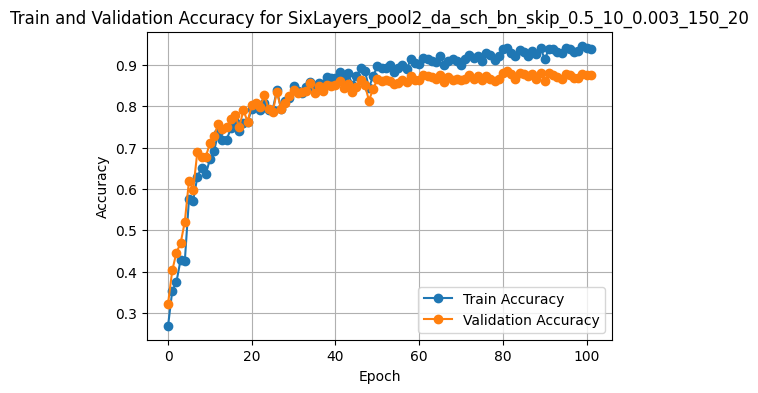

In [10]:
# 6 layers, pooling, da, sch, batchnorm, skip connections
learning_rate = 0.003
num_epochs = 150
patience = 20

gamma = 0.5
step_size = 10

model_name = f"SixLayers_pool2_da_sch_bn_skip_{gamma}_{step_size}_{learning_rate}_{num_epochs}_{patience}"
os.makedirs(f"models/{model_name}", exist_ok=True)

class SixLayerPoolCNN(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)

    def forward(self, x):
        # Block 1: conv1 + conv2 with skip
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  # skip connection
        x = self.pool(x)

        # Block 2: conv3 + conv4 with skip
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  # skip connection
        x = self.pool(x)

        # Block 3: conv5 + conv6 with skip
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  # skip connection

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SixLayerPoolCNN().to(device)

if not local_run:
    n_runs = 3
    skip_training = False
else:
    n_runs = 1
    params_saved = list(Path(f"models/{model_name}").glob("*.tar"))
    outputs_saved = list(Path(f"models/{model_name}").glob("*outputs_epoch_*.pt"))
    grads_saved = list(Path(f"models/{model_name}").glob("*grads_epoch_*.pt"))
    skip_training = params_saved and outputs_saved and grads_saved

test_acc_bm = []
for i in range(n_runs):
    optimizer_instance = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer_instance, step_size=step_size, gamma=gamma)
    optimizer_callable = lambda params, lr: optimizer_instance
    test_acc = train_eval(model, model_name, local_run, nn.CrossEntropyLoss(), optimizer_callable, cnn_trainloader_da, cnn_testloader_da, cnn_valloader_da, device, skip_training, num_epochs = num_epochs, patience = patience, learning_rate = scheduler, seed=i)
    test_acc_bm.append(test_acc)
    torch.save(test_acc_bm, f"models/{model_name}/{model_name}_test_acc_bm.pt")
    if not local_run and i==2:
        !zip -r {model_name}.zip {model_name}
        files.download(f"{model_name}.zip")

plot_epoch_accuracies(model_name)

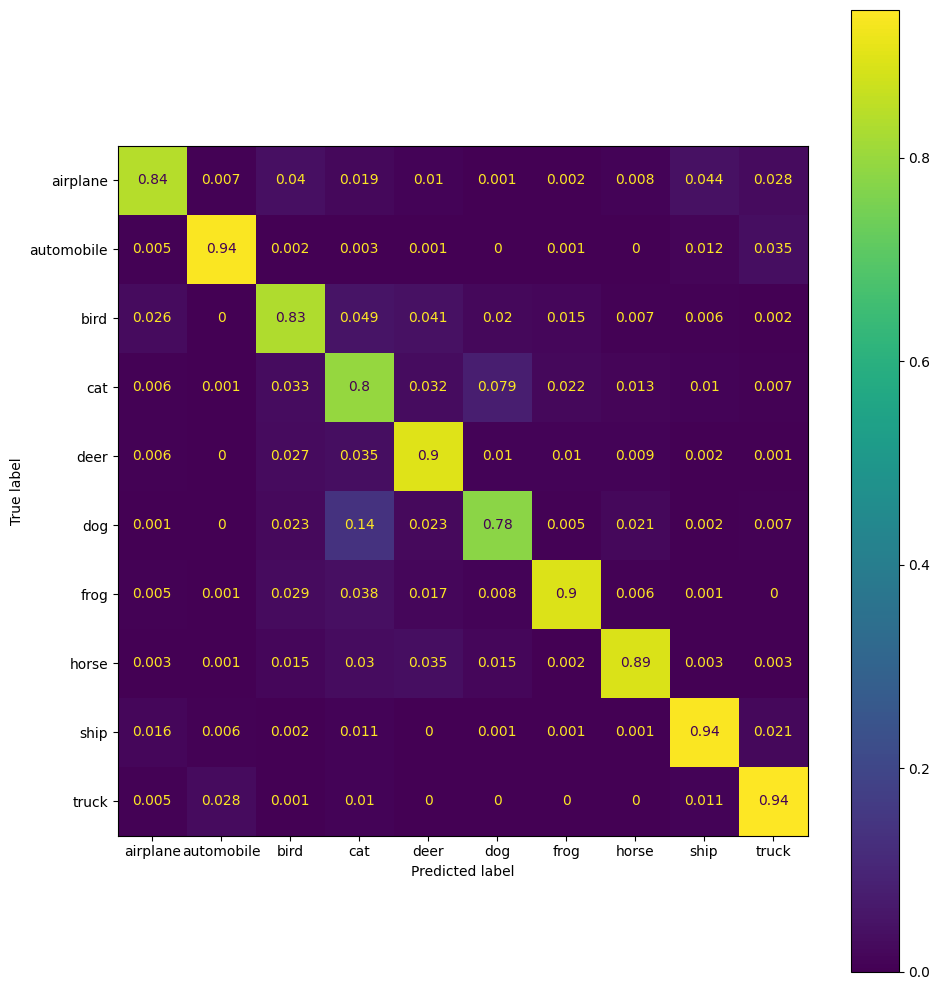

SixLayerPoolCNNanalysis(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, t

In [12]:
from sklearn import metrics
import cv2

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
model.eval()
state_dict = torch.load(f"models/{model_name}/{model_name}_prm.tar", map_location=device)

true_preds, count = 0., 0
test_labels = []
predicted_labels = []
for imgs, labels in cnn_testloader_da:
    imgs, labels = imgs.to(device), labels.to(device)
    with torch.no_grad(): 
        preds = model(imgs).argmax(dim=-1)
        test_labels.extend(labels.tolist())
        predicted_labels.extend(preds.tolist())

cm = metrics.confusion_matrix(test_labels, predicted_labels, normalize = 'true')
disp = metrics.ConfusionMatrixDisplay(cm,  display_labels = class_names)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

class SixLayerPoolCNNanalysis(nn.Module):
    def __init__(self):
        super(SixLayerPoolCNNanalysis, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(128 * 8 * 8, 10)
        self.gradients = None

    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        # Block 1: conv1 + conv2 with skip
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  # skip connection
        x = self.pool(x)

        # Block 2: conv3 + conv4 with skip
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  # skip connection
        x = self.pool(x)

        # Block 3: conv5 + conv6 with skip
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  # skip connection
        x.register_hook(self.activations_hook)
        # or it should be h = x.register_hook(self.activations_hook)?
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self, x):
        # Block 1
        out1 = F.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))
        x = F.relu(out2 + out1)  
        x = self.pool(x)
        # Block 2
        out3 = F.relu(self.bn3(self.conv3(x)))
        out4 = self.bn4(self.conv4(out3))
        x = F.relu(out4 + out3)  
        x = self.pool(x)
        # Block 3
        out5 = F.relu(self.bn5(self.conv5(x)))
        out6 = self.bn6(self.conv6(out5))
        x = F.relu(out6 + out5)  
        return x

model_anal = SixLayerPoolCNNanalysis()
model_anal.load_state_dict(state_dict)
model_anal.eval()

In [249]:
macro_f1 = metrics.f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1 Score: {macro_f1}")

Macro F1 Score: 0.8773294997569063


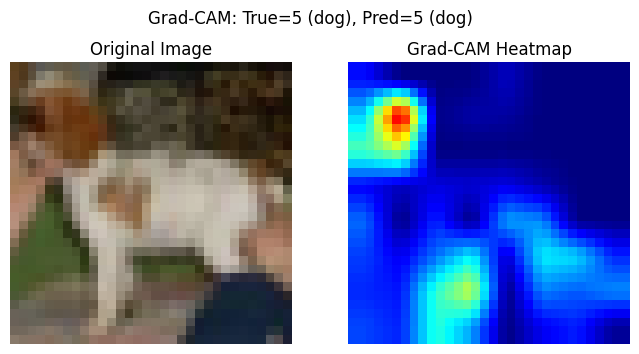

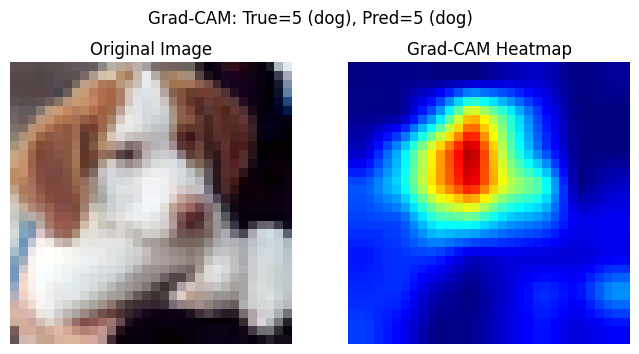

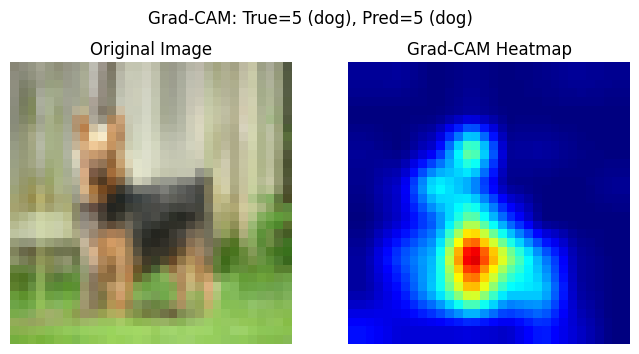

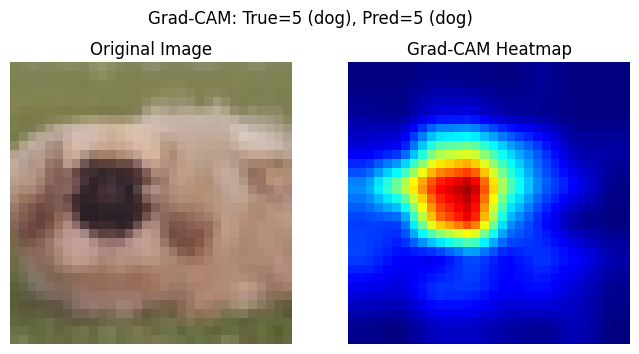

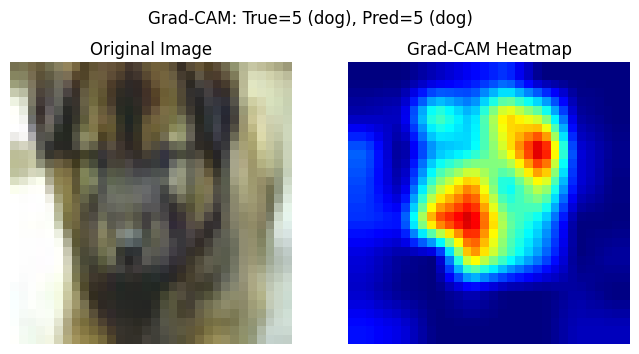

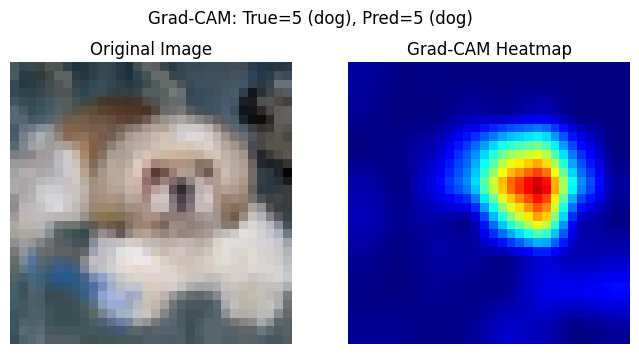

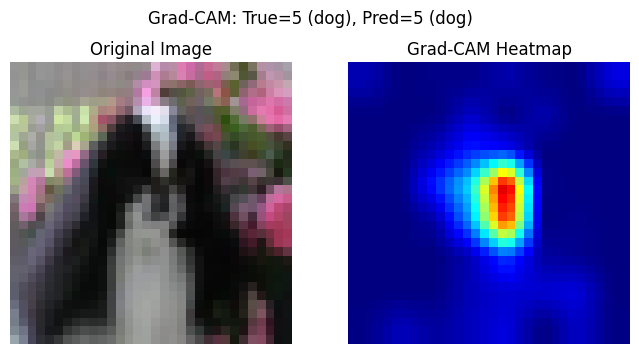

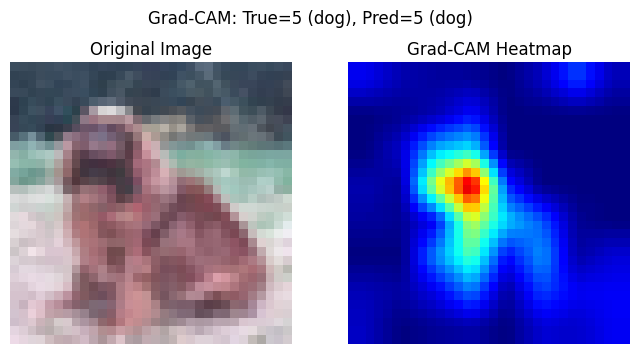

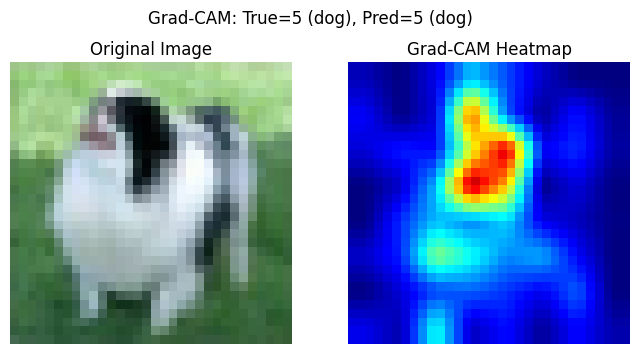

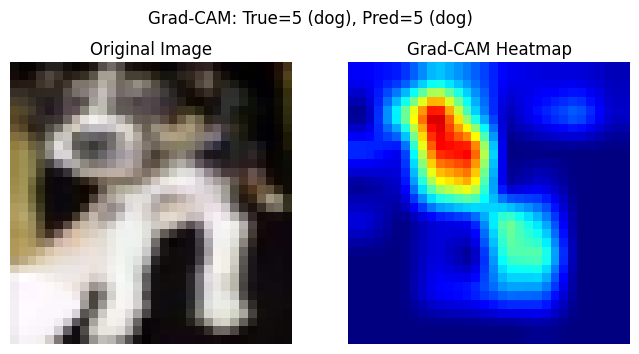

In [13]:
dog_label = 5  # 'dog'

mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]

# Find indices where true label is dog and predicted as dog
dog_as_dog_idxs = [i for i, (t, p) in enumerate(zip(test_labels, predicted_labels))
                   if t == dog_label and p == dog_label][:30]

images_nr = 10
for i in range(images_nr):
    img = cnn_testloader_da.dataset[dog_as_dog_idxs[i]][0].unsqueeze(0).to(device)
    img_plot = test_dataset[dog_as_dog_idxs[i]][0]
    img_plot = img_plot * torch.tensor(std).view(3,1,1) + torch.tensor(mean).view(3,1,1)  # unnormalize for plotting
    output = model_anal(img)

    # pick class
    pred_class = output.argmax(dim=1)

    # backprop
    model_anal.zero_grad()
    output[0, pred_class].backward()

    # get gradients + activations
    gradients = model_anal.get_activations_gradient()
    activations = model_anal.get_activations(img)

    # pool gradients
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    # weight channels
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]

    # create heatmap
    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = torch.relu(heatmap)
    heatmap /= torch.max(heatmap)

    heatmap = heatmap.detach().cpu().numpy()
    heatmap = cv2.resize(heatmap, (32, 32))  # Resize to match CIFAR-10 image size (32x32)

    # Get original image
    img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()

    # Apply colormap to heatmap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_plot.permute(1,2,0))
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(heatmap_colored)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")
    plt.suptitle(f"Grad-CAM: True={test_labels[dog_as_dog_idxs[0]]} (dog), Pred={pred_class.item()} (dog)")
    plt.show()



Seems to focus on the snout (high contrast around it), or the area between the eyes: my guess is it's recognising the bridge of the snout, which is more innlaid in dogs than it is in cats. in standing position: it recognizes how their legs are at an angle when they stand.

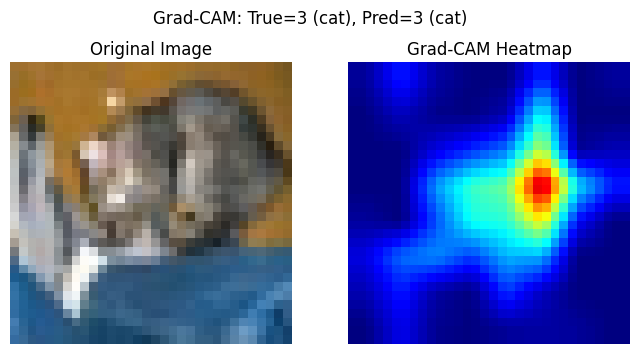

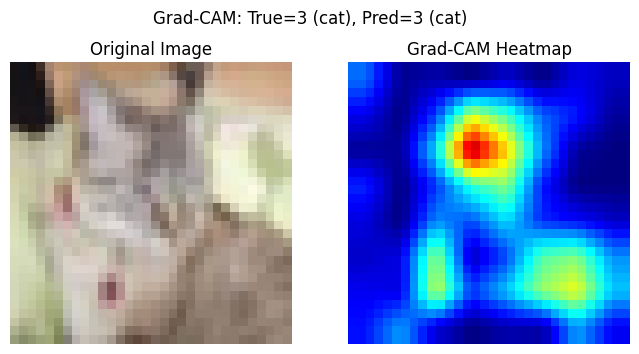

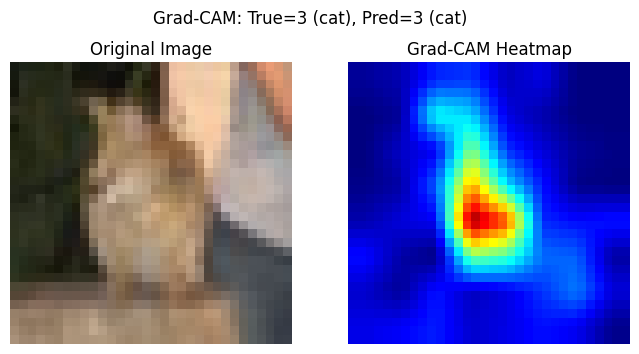

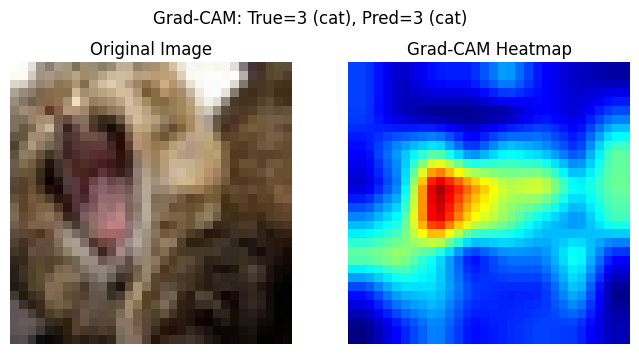

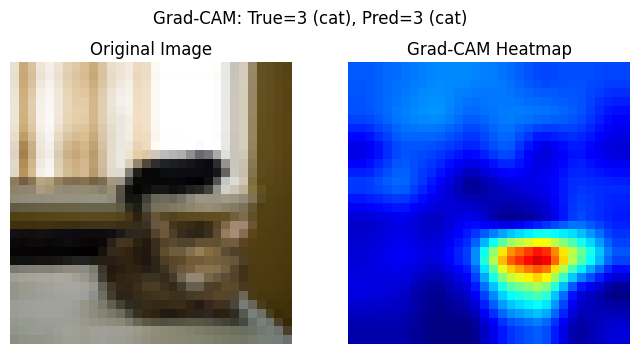

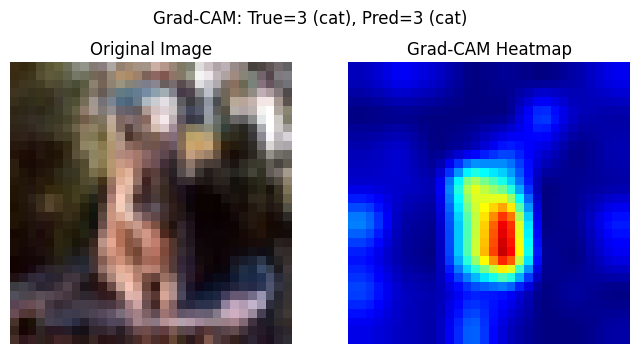

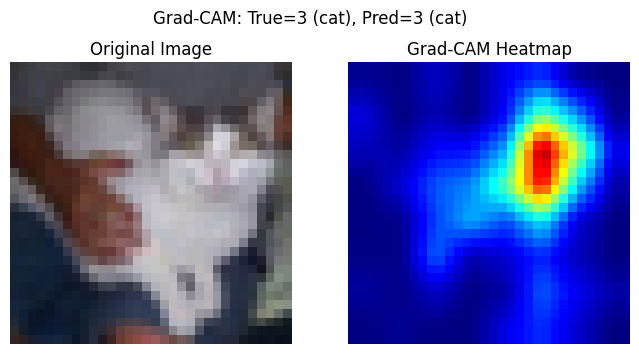

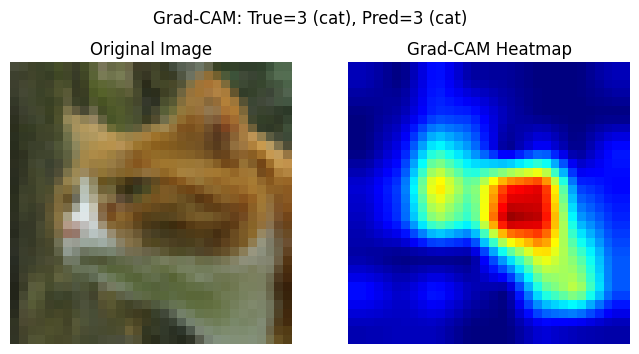

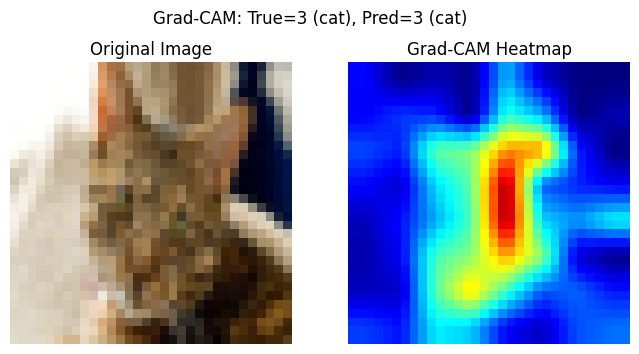

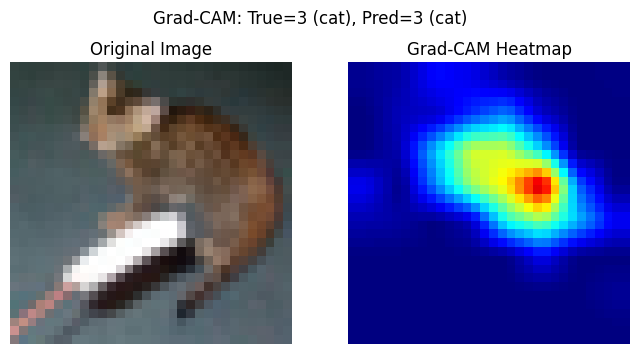

In [14]:
cat_label = 3  # 'cat'

# Find indices where true label is cat and predicted as cat
cat_as_cat_idxs = [i for i, (t, p) in enumerate(zip(test_labels, predicted_labels))
                   if t == cat_label and p == cat_label][:30]

nr_images = 10
for i in range(nr_images):
    img = cnn_testloader_da.dataset[cat_as_cat_idxs[i]][0].unsqueeze(0).to(device)
    img_plot = test_dataset[cat_as_cat_idxs[i]][0]
    img_plot = img_plot * torch.tensor(std).view(3,1,1) + torch.tensor(mean).view(3,1,1)  # unnormalize for plotting
    output = model_anal(img)

    # pick class
    pred_class = output.argmax(dim=1)

    # backprop
    model_anal.zero_grad()
    output[0, pred_class].backward()

    # get gradients + activations
    gradients = model_anal.get_activations_gradient()
    activations = model_anal.get_activations(img)

    # pool gradients
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    # weight channels
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]

    # create heatmap
    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = torch.relu(heatmap)
    heatmap /= torch.max(heatmap)

    heatmap = heatmap.detach().cpu().numpy()
    heatmap = cv2.resize(heatmap, (32, 32))  # Resize to match CIFAR-10 image size (32x32)

    # Get original image
    img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()

    # Apply colormap to heatmap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_plot.permute(1,2,0))
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(heatmap_colored)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")
    plt.suptitle(f"Grad-CAM: True={test_labels[cat_as_cat_idxs[0]]} (cat), Pred={pred_class.item()} (cat)")
    plt.show()



More focus on the triangular ears, the triangular face shape and their posture (hind legs) when they are elaying down.


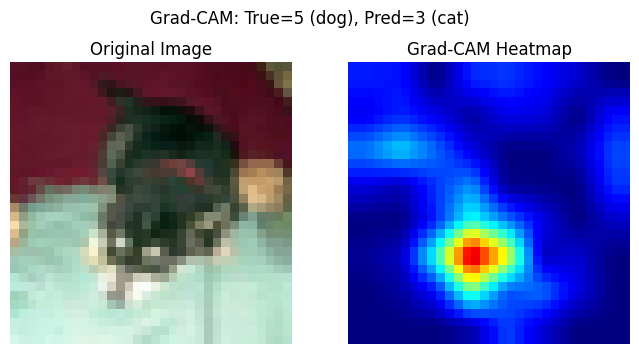

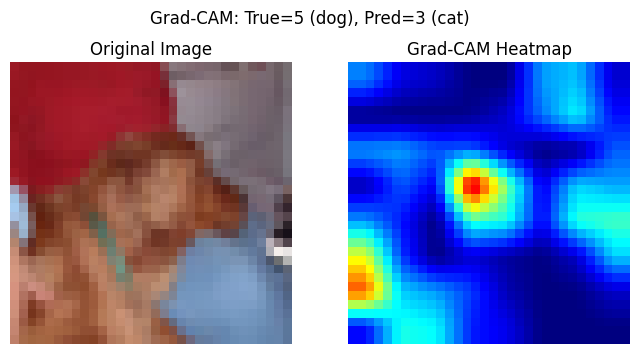

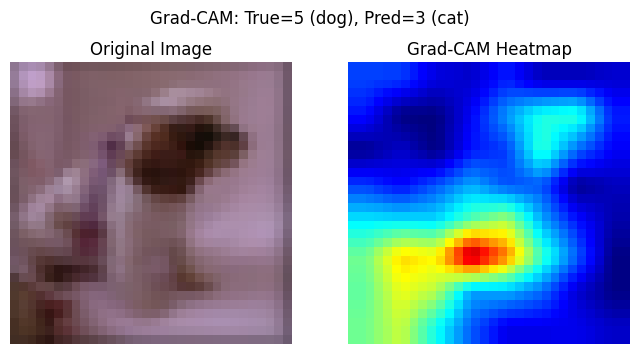

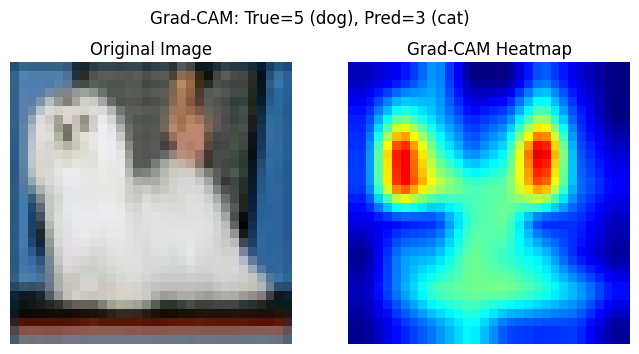

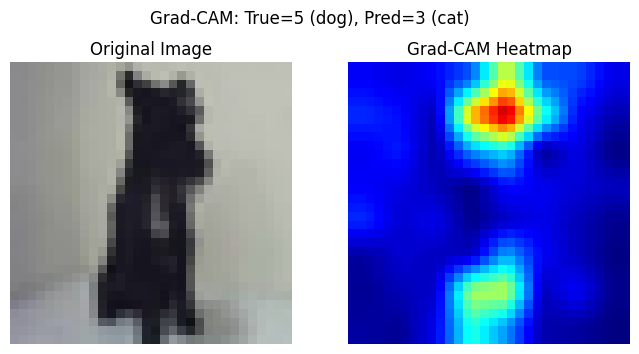

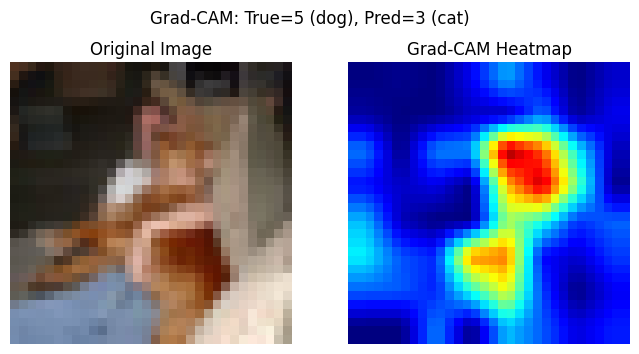

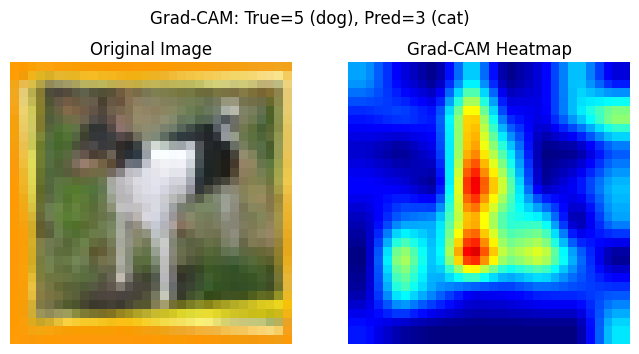

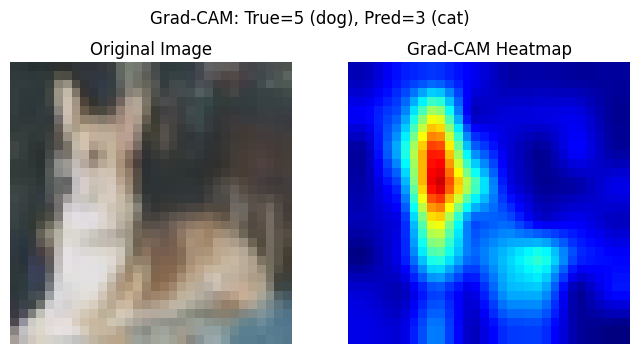

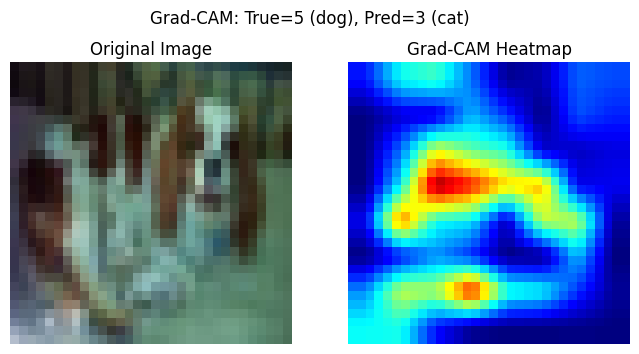

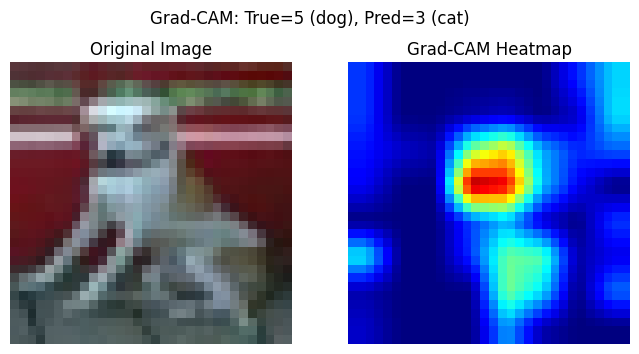

In [15]:
cat_label = 3
# Find indices where true label is dog but predicted as cat
dog_as_cat_idxs = [i for i, (t, p) in enumerate(zip(test_labels, predicted_labels))
                   if t == dog_label and p == cat_label][:15]


for i in range(10):
    img = cnn_testloader_da.dataset[dog_as_cat_idxs[i]][0].unsqueeze(0).to(device)
    img_plot = test_dataset[dog_as_cat_idxs[i]][0]
    img_plot = img_plot * torch.tensor(std).view(3,1,1) + torch.tensor(mean).view(3,1,1)  # unnormalize for plotting
    output = model_anal(img)

    # pick class
    pred_class = output.argmax(dim=1)

    # backprop
    model_anal.zero_grad()
    output[0, pred_class].backward()

    # get gradients + activations
    gradients = model_anal.get_activations_gradient()
    activations = model_anal.get_activations(img)

    # pool gradients
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    # weight channels
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]

    # create heatmap
    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = torch.relu(heatmap)
    heatmap /= torch.max(heatmap)

    heatmap = heatmap.detach().cpu().numpy()
    heatmap = cv2.resize(heatmap, (32, 32))  # Resize to match CIFAR-10 image size (32x32)

    # Get original image
    img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()

    # Apply colormap to heatmap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_plot.permute(1,2,0))
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(heatmap_colored)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")
    plt.suptitle(f"Grad-CAM: True={test_labels[dog_as_cat_idxs[0]]} (dog), Pred={pred_class.item()} (cat)")
    plt.show()


In a lot of these images, the snout is not recognizable, either due to a weird angle, or due to low contrast between the snout and the color of the hair around it.
The model has learned a shortcut feature for “dog” — it heavily relies on snout/face-specific patterns. When that feature is clear, it succeeds; when it’s obscured (angle, lighting, contrast), performance drops. The CNN has insufficient robustness to viewpoint + appearance variation. It likely underutilizes global shape, texture, or contextual cues (eg the white dog has very long hair for cat).

One possible solution would be to add data augumentation that specifically targets this feature over-reliance, such as 'Cutout' data augmenttion which randomly masks square regions of the input image during training. 
Another regularization strategy for reducing feature over-reliance is the 'CutMix' augmentation. Here, patches are cut and pasted among training images where the ground truth labels are also mixed proportionally to the area of the patches. This way, we might end up with a training image which contains the head of a cat, but the body of a dog. Trained on this example, the classifier use the cat's head to make a prediction of the label 'cat', and the dog's feet to make a prediction of a 'dog' label. The technique is similar to the 'Cutout' technique, only it uses the training pixels more efficiently since we are not replacing a random part of the image with black pixels. 

Another improvement could come through changing the architecture. Aside from adding more layers and increasing the channel width, we could adjust the way skip connections are used. As mentioned before, it seems that the network is not using texture cures enough. Adjusting the skip connections would allow the network to better combine the low- and high-level features. In the current set-up, we use max-pooling after adding the identity path to the convolution path. As these paths are pooled together, some of the low-level information likely gets lost. Conversely, in famous ResNet architectures the downsampling occurs before adding the identity and the convolution path. This allows the low level information to flow into the deeper parts of the network with less alteration. 

## Impact of parameters on accuracy

In [253]:
test_acc_dict

{'OneLayer_50000_10000_10': [0.5984, 164298],
 'FourLayers_pool_0.001_60_7': [0.7409, 267434],
 'FourLayers_pool_gap_lc_da_0.001_60_7': [0.8173, 267434],
 'SixLayers_pool2_da_bn_0.001_60_10': [0.863, 369834],
 'SixLayers_pool2_0.001_60_10': [0.762, 368938],
 'SixLayers_pool_da_0.001_60_10': [0.8481, 368938],
 'SixLayers_pool2_da_bn_0.001_100_10': [0.8696, 369834],
 'SixLayers_pool3_da_bn_0.001_60_10': [0.8642, 615594],
 'SixLayers_pool2_da_bn_skip_0.001_60_10': [0.8572, 369834],
 'SixLayers_pool2_da_bn_skip_0.001_100_10': [0.866, 369834],
 'SixLayers_pool2_da_sch_bn_skip_0.5_10_0.003_60_10': [0.8596, 369834],
 'SixLayers_pool2_da_bn_skip_sch_0.001_60_10': [0.8271, 369834]}

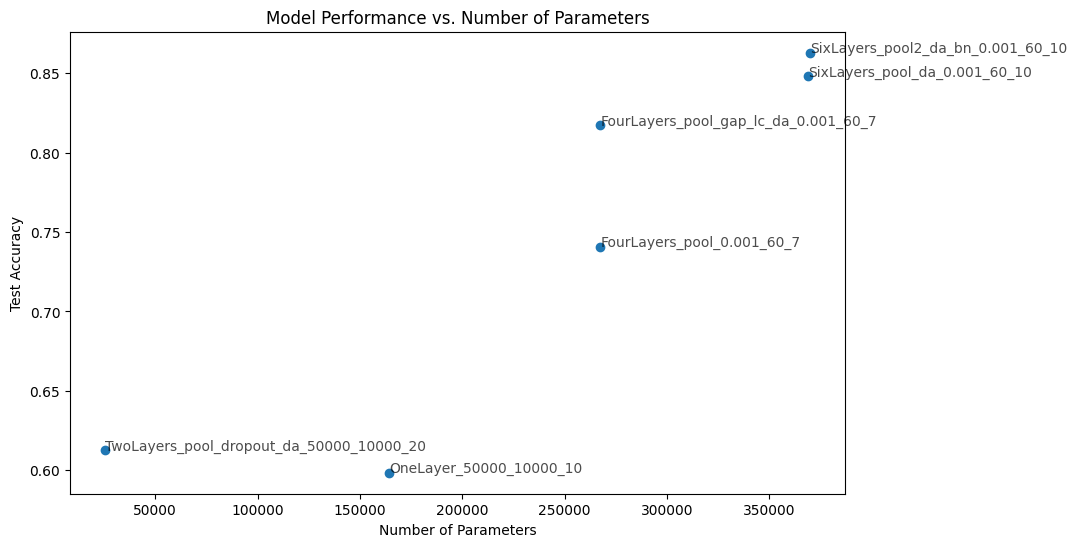

In [257]:
models = ['OneLayer_50000_10000_10','TwoLayers_pool_dropout_da_50000_10000_20', 'FourLayers_pool_0.001_60_7', 'FourLayers_pool_gap_lc_da_0.001_60_7', 'SixLayers_pool_da_0.001_60_10', 'SixLayers_pool2_da_bn_0.001_60_10']
test_accuracies = [test_acc_dict[model][0] for model in models]
parameter_counts = [test_acc_dict[model][1] for model in models]

plt.figure(figsize=(10, 6))
plt.scatter(parameter_counts, test_accuracies)

# Add model names as labels for each point
for i, model in enumerate(models):
    plt.annotate(model, (parameter_counts[i], test_accuracies[i]), fontsize=10, alpha=0.7)

plt.xlabel('Number of Parameters')
plt.ylabel('Test Accuracy')
plt.title('Model Performance vs. Number of Parameters')
plt.show()
